# model7 SuperPixelのGNN
SLICtile 20μm 118症例、Radiusグラフ, 5hop, sampling数3, 64次元
241118

In [1]:
import os
import numpy as np
import pandas as pd
import tqdm as tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

import torch_geometric
from torch_geometric.data import Data
from torch_geometric.data import NeighborSampler as RawNeighborSampler
from torch_geometric.nn import SAGEConv
from torch_cluster import random_walk

from sklearn.neighbors import radius_neighbors_graph

import networkx as nx
import matplotlib.pyplot as plt
import sklearn.cluster as cluster
import seaborn as sns
import matplotlib.colors as mcolors
from glob import glob
import h5py

## HDF5作成

In [3]:
paths = glob("labelRatio_241117/*.txt")
len(paths)

118

In [4]:
with h5py.File("GNN_InOut.h5", mode="w") as f:
    for path in tqdm.tqdm(paths):
        samplename = path.split("\\")[-1]
        samplename = samplename.split("_HE")[0]
        f.create_group(samplename)

100%|██████████| 118/118 [00:00<00:00, 58983.18it/s]


In [5]:
className = ["Background","Immune cells", "plasma", "Fibro(loose)", "Fibro(dense,regular)",
"Fibro(dense,irregular)", "lining", "vessel", "vessel(large)",
"adipose", "Stroma", "muscle", "RBC"]

with h5py.File("GNN_InOut.h5", mode="a") as f:
    for path in tqdm.tqdm(paths):
        samplename = path.split("\\")[-1]
        samplename = samplename.split("_HE")[0]

        # QuPathからの書き出しファイル読み込み
        df = pd.read_csv(path,index_col=0,sep="\t")

        f[samplename].create_dataset("index", data=df.index.to_numpy())
        ## -- タイルの中心座標 --
        points = df[["x","y"]].to_numpy()

        # h5に記録
        f[samplename].create_dataset("coord", data = points, compression = "gzip")

        ## -- タイルの入力特徴量 ラベル割合 --
        df.drop(columns=["x","y"], inplace=True)

        # 未名の列をすべて削除
        df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

        # 各行の合計を計算
        row_sums = df.sum(axis=1)
        # 各行をその合計で割る
        df_ratio = df.div(row_sums, axis=0)
        # ノード特徴行列
        x = df_ratio.to_numpy()
        # h5に記録
        f[samplename].create_dataset("input_feat", data = x, compression = "gzip")

        # Tile内の最大組織割合
        idmax = df_ratio.idxmax(axis=1)
        idmax = [ int(i) for i in list(idmax)]
        labelmax = np.array(className)[idmax]

        f[samplename].create_dataset("tile_maxID", data = idmax, compression = "gzip")
        f[samplename].create_dataset("tile_maxLabel", data = np.array(labelmax, dtype='S'), compression = "gzip")

100%|██████████| 118/118 [00:43<00:00,  2.74it/s]


In [7]:
with h5py.File("GNN_InOut.h5", mode="r") as f:
    groups = list(f.keys())

## Radius graph作り 20 μmタイル辺で作っていて、隣のタイルの中心座標の距離は20 μm程度。斜め上は20*√2で30μm閾値でやれば斜め位置も拾えるはず。
### 実際は1.1 μm/pxのピクセル座標なので35を閾値としよう
20 * sqrt(2) * 1.1023 = 31.17775

In [8]:
# 接続有りとする距離の閾値
radius = 35

with h5py.File("GNN_InOut.h5", mode="a") as f:
    for donor in tqdm.tqdm(groups):
        points = f[donor]["coord"]
        adj_matrix = radius_neighbors_graph(X=points, radius=radius)
        edge_index = np.argwhere(adj_matrix > 0)
        f[donor].create_dataset("edge_index", data=edge_index, compression="gzip")

100%|██████████| 118/118 [01:23<00:00,  1.41it/s]


## Batch Dataset作り

In [2]:
data_list = []

with h5py.File("GNN_InOut.h5", mode="r") as f:
    donors = list(f.keys())
    for donor in tqdm.tqdm(donors):
        edge_index = f[donor]["edge_index"]
        features = f[donor]["input_feat"]

        # Datasetの中身にアクセス（[:]）
        x = torch.from_numpy(features[:]).to(torch.float32)
        edge_index = torch.from_numpy(edge_index[:]).to(torch.long)

        data = Data(x=x, edge_index=edge_index.t().contiguous(), donor=donor)
        data_list.append(data)

100%|██████████| 118/118 [00:10<00:00, 11.35it/s]


In [3]:
dataset = torch_geometric.data.Batch.from_data_list(data_list)

In [4]:
dataset

DataBatch(x=[12100353, 12], edge_index=[2, 94575914], donor=[118], batch=[12100353], ptr=[119])

## GNNに必要な機能の用意 混合精度版

In [5]:
from torch_geometric.data import NeighborSampler as RawNeighborSampler
from torch_cluster import random_walk

class NeighborSampler(RawNeighborSampler):
    """
    PyGのNeighborSamplerのsample関数を上書きしたNeighborSamplerを定義
    sample関数以外は全て親クラスから継承
    
    input: バッチサイズ分のノードidx
    
    処理:
     1. ノードが繋がる隣接ノードからランダムに1つ抜き出す。
     2. グラフ全体からランダムにノードを抽出する。
     3. バッチノード、ポジコンノード、ネガコンノードを親クラスのsample関数に渡して、
     　　各ノードが持つ連結情報を取得する

    """

    # サンプリング機能
    def sample(self, batch):
        batch = torch.tensor(batch)

        ## ----- 処理1 random walkでポジコンノード作成 -----
        
        # Sparseなtensorからrow,col,valueを取り出す方法 https://pytorch-geometric.readthedocs.io/en/latest/notes/sparse_tensor.html
        row,col,_ = self.adj_t.coo()

        # start位置がbatchで1stepランダムに進んだ接続を取得
        pos_batch = random_walk(
            row=row, # 接続元ノード番号
            col=col, # 接続先ノード番号
            start=batch, # スタートノード
            walk_length=1, # 1エッジ分進む
            coalesced=False # 並び替えは時間がかかるのでオフ
        )
        
        # [スタートノード、進んだ先]情報から進んだ先だけを取り出す = ポジコンノード
        pos_batch = pos_batch[:,1] 

        ## ----- 処理2 random samplingでネガコンノード作成 -----
        # ランダムにノードを取得。
        neg_batch = torch.randint(
            low=0,
            high=self.adj_t.size(1), 
            size=(batch.numel(), ), # batch.numel()は要素数を返す。(要素数, )の形状
            dtype=torch.long)

        ## ----- 処理3 集めたノードを親クラスのsample関数に渡す -----
        # 全て結合（posとnegだけじゃなくてbatchも一緒に）
        batch = torch.cat([batch, pos_batch, neg_batch], dim=0)

        # 継承元のsampleに再度渡して出力を整える。
        batch = super(NeighborSampler, self).sample(batch)    
        
        return batch

In [6]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class SAGE(torch.nn.Module):
    def __init__(self,
                 in_channels,
                 hidden_channels,
                 output_channels,
                 num_layers # hop数
                ):
        
        super(SAGE, self).__init__()
        self.num_layers = num_layers

        # hop数の数だけSAGEConvを行う
        self.convs = nn.ModuleList() # 層のインスタンス入れ先
        for i in range(num_layers):
            # layerの1層目はin_channels、2層目以降はhidden_ch数が入力
            in_channels = in_channels if i==0 else hidden_channels
            # 最終層まではhidden_ch数が出力
            out_channels = hidden_channels if i < num_layers-1 else output_channels
            
            # l2正則化項を使うかどうか　最終層以外は使用する
            norm = True if i < num_layers-1 else False

            # SAGEConvのインスタンスを作成して、convsに追記
            self.convs.append(SAGEConv(
                in_channels, out_channels, 
                normalize=norm, 
                root_weight=True))
            
    def forward(self, x, adjs):
        # hopごとに接続行列があるので、それぞれで処理
        # 要素番号が若いほど、hop数が大きいグラフ
        # 遠くのhopを考慮したグラフから順次SAGEConvに渡してノード特徴量を更新していく
        for i, (edge_index, _, size) in enumerate(adjs):
            # 中心ノードからk hopまでのノードを取り出す ※ バッチのノード特徴行列はhopで取り出された順になっている。
            x_target = x[:size[1]]

            # SAGEConv
            x = self.convs[i]((x, x_target), edge_index)
            
            # 最後の層（k=1）以外ではReLUとDropout
            if i != self.num_layers-1:
                x = x.relu()
                x = F.dropout(x, p=0.25, training=self.training)
        return x

    # 訓練済みモデルで予測する用 hopを取り出すとかはなく、決定されたパラメーターでノードを更新する
    def full_forward(self, x, edge_index):
        for i,conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i != self.num_layers - 1:
                x = x.relu()
                x = F.dropout(x, p=0.25, training=self.training)
        return x

In [7]:
def train(model, x, optimizer, train_loader, device="cuda", use_amp=True):

    num_nodes = x.shape[0]
    model.train()
    model = model.to(device)
    x = x.to(device)
    total_loss = 0

    scaler = torch.amp.GradScaler(enabled=use_amp)

    # train_loaderからバッチの取り出し
    pbar = tqdm.tqdm(train_loader)
    for batch_size, n_id, adjs in pbar:
        # 1: batch size, 2: バッチ内の全ノードのID, 3: 接続行列のエッジID
        # 3の接続行列のエッジIDはhopごとに分かれている。
        adjs = [adj.to(device) for adj in adjs]

        with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_amp):
            ## モデルを通す
            out = model(x[n_id], adjs)

            # batch, pos_batch, neg_batchのそれぞれの出力取得
            # それぞれのbatchサイズは同じなので、3分割するだけでよい
            out, pos_out, neg_out = out.split(out.size(0) // 3, dim=0)

            ## 損失の計算
            # outとpos_outの損失
            pos_loss = F.logsigmoid((out * pos_out).sum(-1)).mean()
            # outとneg_outの損失
            neg_loss = F.logsigmoid(-(out * neg_out).sum(-1)).mean()
            # total loss: logsigmoidの値は基本マイナスなので、正負逆にして損失を正に
            loss = -pos_loss - neg_loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

        total_loss += float(loss) * out.size(0)
        pbar.set_description(
                f"loss: {loss:.4f}, pos_loss: {pos_loss:.4f}, neg_loss: {neg_loss:.4f}"
        )

    return total_loss / num_nodes

## 訓練　バッチサイズ8192

In [8]:
sampling = 3
num_layers = 5
batch_size =8192
device = "cuda"

# バッチコミュニティの抽出器のインスタンス
train_loader = NeighborSampler(
    dataset.edge_index,
    sizes=[3]*num_layers, 
    batch_size=batch_size,
    shuffle=True,
    num_nodes=dataset.num_nodes,
    drop_last=True
)

# モデルインスタンス
model = SAGE(
    in_channels=dataset.num_node_features,
    hidden_channels=256,
    output_channels=64,
    num_layers=num_layers)

# 最適化関数
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

c:\Users\admin\anaconda3\envs\PyG\Lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.NeighborSampler' is deprecated, use 'loader.NeighborSampler' instead
  warnings.warn(out)


### train

In [9]:
save_dir = "model_checkpoint_241118"
os.makedirs(save_dir,exist_ok=True)

best_loss = 1
save_path = f"{save_dir}/best_checkpoint.pt"

history = []

for i in range(40):
    loss = train(model, dataset.x, optimizer, train_loader,device)
    print(loss)
    history.append(loss)
    if loss < best_loss:
        torch.save(model.state_dict(), save_path)
        best_loss = loss

loss: 0.8610, pos_loss: -0.0698, neg_loss: -0.7911: 100%|██████████| 1477/1477 [3:20:46<00:00,  8.16s/it]  


0.9117192002709549


loss: 0.8360, pos_loss: -0.0668, neg_loss: -0.7692: 100%|██████████| 1477/1477 [3:41:45<00:00,  9.01s/it]  


0.8494135867100323


loss: 0.8388, pos_loss: -0.0592, neg_loss: -0.7796: 100%|██████████| 1477/1477 [3:35:20<00:00,  8.75s/it]  


...

0.7688565433632133


loss: 0.7689, pos_loss: -0.0285, neg_loss: -0.7404: 100%|██████████| 1477/1477 [3:40:25<00:00,  8.95s/it]  


0.7686928464423595


loss: 0.7662, pos_loss: -0.0285, neg_loss: -0.7377: 100%|██████████| 1477/1477 [3:38:27<00:00,  8.87s/it]  

0.7686910034563532


#### --> 10.8GBで訓練開始　その後 18GBぐらいまで上昇


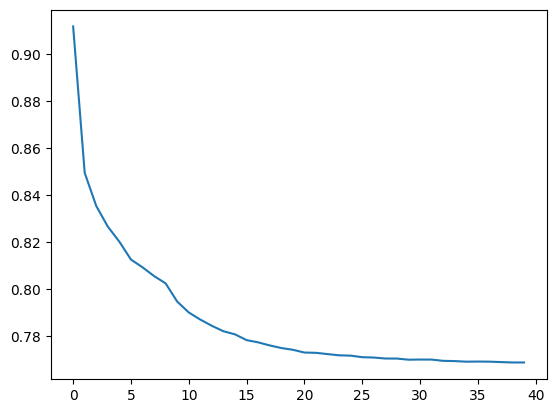

In [10]:
plt.plot(history)

## モデルの保存

In [11]:
torch.save(model,"CancerCell_model_20um_5hop3sample64feat_241118.pt")

## 訓練済みモデルで予測

In [12]:
model = model.to("cpu")
torch.cuda.empty_cache()

In [13]:
## hdf5を読み込んでDataオブジェクトを作ってモデルに渡す。予測結果をhdf5に書き込み
with h5py.File("GNN_InOut.h5", mode="a") as f:
    donors = list(f.keys())
    for donor in tqdm.tqdm(donors):
        edge_index = f[donor]["edge_index"]
        features = f[donor]["input_feat"]

        # Datasetの中身にアクセス（[:]）
        x = torch.from_numpy(features[:]).to(torch.float32)
        edge_index = torch.from_numpy(edge_index[:]).to(torch.long)

        # Dataインスタンス作成
        data = Data(x=x, edge_index=edge_index.t().contiguous(), donor=donor)
        # 訓練済みモデルで特徴抽出
        pred_features = model.full_forward(
            data.x.cpu(),
            data.edge_index.cpu()
            ).detach().numpy()
        # hdf5に書き込み
        f[donor].create_dataset("pred_features", data=pred_features, compression = "gzip")

100%|██████████| 118/118 [05:22<00:00,  2.73s/it]


## QuPath用に特徴量書き出し

In [14]:
with h5py.File("GNN_InOut.h5", mode="r") as f:
    # ファイル内の全データセットやグループを再帰的に表示
    def print_hdf5_structure(name, obj):
        print(name, obj)

    # ファイル全体を表示
    f.visititems(print_hdf5_structure)

D001 <HDF5 group "/D001" (7 members)>
D001/coord <HDF5 dataset "coord": shape (125418, 2), type "<f8">
D001/edge_index <HDF5 dataset "edge_index": shape (954766, 2), type "<i4">
D001/index <HDF5 dataset "index": shape (125418,), type "|O">
D001/input_feat <HDF5 dataset "input_feat": shape (125418, 12), type "<f8">
D001/pred_features <HDF5 dataset "pred_features": shape (125418, 64), type "<f4">
D001/tile_maxID <HDF5 dataset "tile_maxID": shape (125418,), type "<i8">
D001/tile_maxLabel <HDF5 dataset "tile_maxLabel": shape (125418,), type "|S22">
D002 <HDF5 group "/D002" (7 members)>
D002/coord <HDF5 dataset "coord": shape (37440, 2), type "<f8">
D002/edge_index <HDF5 dataset "edge_index": shape (622792, 2), type "<i4">
D002/index <HDF5 dataset "index": shape (37440,), type "|O">
D002/input_feat <HDF5 dataset "input_feat": shape (37440, 12), type "<f8">
D002/pred_features <HDF5 dataset "pred_features": shape (37440, 64), type "<f4">
D002/tile_maxID <HDF5 dataset "tile_maxID": shape (3744

In [15]:
save_dir = "SLICTile_Features_241125"
os.makedirs(save_dir, exist_ok=True)

with h5py.File("GNN_InOut.h5", mode="r") as f:
    donors = list(f.keys())
    for donor in tqdm.tqdm(donors):
        features = f[donor]["pred_features"][:]
        index = f[donor]["index"][:].astype(str)

        write_df = pd.DataFrame(features,index=index)
        write_df.to_csv(f"{save_dir}/{donor}.txt",sep="\t",index_label="ID")


100%|██████████| 118/118 [06:53<00:00,  3.51s/it]


# クラスタリング
241125

In [ ]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import networkx as nx
import matplotlib.pyplot as plt
import sklearn.cluster as cluster
import seaborn as sns
import matplotlib.colors as mcolors
from glob import glob
import h5py

### クラスタリングのときはinfo_dict再開するか。plotコマンド直すのめんどいから

In [2]:
info_dict = dict()

In [3]:
with h5py.File("GNN_InOut.h5", mode="r") as f:
    donors = list(f.keys())
    for donor in tqdm(donors):
        coords = f[donor]["coord"][:]
        index = f[donor]["index"][:].astype(str)
        maxID = f[donor]["tile_maxID"][:]
        input_df = f[donor]["input_feat"][:]
        input_df = pd.DataFrame(input_df, index=index)
        coord_df = pd.DataFrame(coords, index=index, columns=["x","y"])

        features = f[donor]["pred_features"][:]
        features = pd.DataFrame(features, index=index)
        info_dict[donor] = {"input_df": input_df,
                            "features": features,
                            "coord": coord_df,
                            "id_max": maxID,
                            "index": input_df.index}

  0%|          | 0/118 [00:00<?, ?it/s]

100%|██████████| 118/118 [00:31<00:00,  3.74it/s]


In [4]:
# Object IDと採用クラスターの初期化対応表を作っておく
patients = info_dict.keys()

for patient in patients:
    index = info_dict[patient]["index"]
    info_dict[patient]["id_cluster"] = { id:None for id in index}

In [5]:
info_dict["D001"]

{'input_df':                                        0    1         2    3         4     5   \
 36e74ff6-f1ef-43b8-83e0-49dd926c91af  0.0  0.0  0.880000  0.0  0.000000  0.12   
 67c7c1dd-6d10-4904-b93f-7cbaa7903978  0.0  0.0  0.000000  0.0  0.000000  1.00   
 1ecb0146-88fe-4d42-b4de-52a3d61f2d7f  0.0  0.0  0.000000  0.0  0.000000  1.00   
 34109e9b-aa95-4eba-ad1a-397617cc8352  0.0  0.0  1.000000  0.0  0.000000  0.00   
 3a797ce1-151c-4553-90e8-62cfa1683fef  0.0  0.0  0.000000  0.0  0.000000  1.00   
 ...                                   ...  ...       ...  ...       ...   ...   
 80df2856-541b-47ed-be00-dbf52f266b17  0.0  0.0  0.135484  0.0  0.864516  0.00   
 1fd70d13-27b1-4403-89b8-7129618cb383  0.0  0.0  0.000000  0.0  1.000000  0.00   
 97c1d186-077f-4cfa-9bc0-9de4c92ceb1b  0.0  0.0  0.000000  0.0  1.000000  0.00   
 51a11b85-aadc-40c5-8408-11c3ebe0fa2a  0.0  0.0  0.000000  0.0  1.000000  0.00   
 7c66a745-073f-44f1-aae4-af41d4c82542  0.0  0.0  0.000000  0.0  1.000000  0.00   
 
  

In [6]:
info_dict["D001"]["input_df"]

,0,1,2,3,4,5,6,7,8,9,10,11
36e74ff6-f1ef-43b8-83e0-49dd926c91af,0.0,0.0,0.880000,0.0,0.000000,0.12,0.0,0.0,0.0,0.0,0.0,0.0
67c7c1dd-6d10-4904-b93f-7cbaa7903978,0.0,0.0,0.000000,0.0,0.000000,1.00,0.0,0.0,0.0,0.0,0.0,0.0
1ecb0146-88fe-4d42-b4de-52a3d61f2d7f,0.0,0.0,0.000000,0.0,0.000000,1.00,0.0,0.0,0.0,0.0,0.0,0.0
34109e9b-aa95-4eba-ad1a-397617cc8352,0.0,0.0,1.000000,0.0,0.000000,0.00,0.0,0.0,0.0,0.0,0.0,0.0
3a797ce1-151c-4553-90e8-62cfa1683fef,0.0,0.0,0.000000,0.0,0.000000,1.00,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
80df2856-541b-47ed-be00-dbf52f266b17,0.0,0.0,0.135484,0.0,0.864516,0.00,0.0,0.0,0.0,0.0,0.0,0.0
1fd70d13-27b1-4403-89b8-7129618cb383,0.0,0.0,0.000000,0.0,1.000000,0.00,0.0,0.0,0.0,0.0,0.0,0.0
97c1d186-077f-4cfa-9bc0-9de4c92ceb1b,0.0,0.0,0.000000,0.0,1.000000,0.00,0.0,0.0,0.0,0.0,0.0,0.0
51a11b85-aadc-40c5-8408-11c3ebe0fa2a,0.0,0.0,0.000000,0.0,1.000000,0.00,0.0,0.0,0.0,0.0,0.0,0.0


### 予測結果の取り出し

In [7]:
results = []

for d in info_dict.values():
    results.append(d["features"])

In [8]:
results

[                                            0         1         2         3   \
 36e74ff6-f1ef-43b8-83e0-49dd926c91af  0.383504 -0.275259  0.156647 -0.359364   
 67c7c1dd-6d10-4904-b93f-7cbaa7903978  0.384282 -0.306483  0.143348 -0.325981   
 1ecb0146-88fe-4d42-b4de-52a3d61f2d7f  0.384122 -0.308882  0.156408 -0.418156   
 34109e9b-aa95-4eba-ad1a-397617cc8352  0.417467 -0.341326  0.147547 -0.373598   
 3a797ce1-151c-4553-90e8-62cfa1683fef  0.409742 -0.353449  0.136093 -0.319062   
 ...                                        ...       ...       ...       ...   
 80df2856-541b-47ed-be00-dbf52f266b17  0.416954  0.401571  0.375511  0.414621   
 1fd70d13-27b1-4403-89b8-7129618cb383  0.308636  0.216143 -0.631313  0.229051   
 97c1d186-077f-4cfa-9bc0-9de4c92ceb1b  0.143559  0.111749 -0.717717  0.048879   
 51a11b85-aadc-40c5-8408-11c3ebe0fa2a  0.407469  0.345048 -0.164273  0.324233   
 7c66a745-073f-44f1-aae4-af41d4c82542  0.390134  0.412708  0.590185  0.329739   
 
                          

In [9]:
import sklearn.cluster as cluster

num_cluster = 12

kmeans = cluster.KMeans(n_clusters=num_cluster, random_state=42)
# 症例ごとの結果を結合してK-meansのfitに渡す
kmeans.fit(np.concatenate(results))
print(np.concatenate(results).shape)

(12100353, 64)


In [10]:
for key, value in tqdm(info_dict.items()):
    info_dict[key]["Cluster"] = kmeans.predict(value["features"])

100%|██████████| 118/118 [00:01<00:00, 75.84it/s] 


In [11]:
def plot_cluster(
    sample_info_dict, num_cluster,
    pt_size=1,
    figsize=(12, 5),
    xmin=None, xmax=None,
    ymin=None, ymax=None,
    className=None,
    celltype_cmap="tab20", cluster_cmap="jet"
):
    df = sample_info_dict["coord"]

    xmin = df["x"].min() if xmin is None else xmin
    xmax = df["x"].max() if xmax is None else xmax
    ymin = df["y"].min() if ymin is None else ymin
    ymax = df["y"].max() if ymax is None else ymax

    _cluster = sample_info_dict['Cluster']
    _df = df.reset_index()

    ind = _df.query("(@xmin <= x <= @xmax) and (@ymin <= y <= @ymax)").index
    _df = _df.loc[ind]
    _cluster = _cluster[ind]
    _label = sample_info_dict["id_max"][ind]
    
    plt.figure(figsize=figsize)

    if className is None:
        className = list(range(1,np.max(_label)+1))
        
    # 左側のプロット
    plt.subplot(121)
    scatter = plt.scatter(x=_df["x"], y=_df["y"],
                          c=_label,
                          s=pt_size, cmap=celltype_cmap,
                          vmin=1, vmax=len(className))
    plt.title("Cell Type")
    
    # 固定された全ラベルを表示する
    cmap_obj = plt.get_cmap(celltype_cmap)
    handles = [plt.Line2D([0], [0], marker='o', color='w', 
                          markerfacecolor=cmap_obj(i/(len(className)-1)), markersize=6) 
               for i in range(len(className))]    
    plt.legend(handles=handles,
               labels=className,
               title='Max label', bbox_to_anchor=(-0.75, 1), loc='upper left')
    
    # 右側のプロット
    plt.subplot(122)    
    scatter = plt.scatter(x=_df["x"], y=_df["y"], c=_cluster,
                          s=pt_size, cmap=cluster_cmap,
                          vmin=0, vmax=num_cluster-1)
    plt.title("Cluster")
    # 固定された全クラスター値のラベルを表示する
    cmap_obj = plt.get_cmap(cluster_cmap)
    handles = [plt.Line2D([0], [0], marker='o', color='w', 
                          markerfacecolor=cmap_obj(i/(num_cluster-1)), markersize=6) 
               for i in range(num_cluster)]
    labels = range(num_cluster)
    plt.legend(handles=handles, labels=labels, title="Cluster",
               bbox_to_anchor=(1.25, 1), loc='upper right')

    # レイアウト調整
    plt.subplots_adjust(right=0.8)
    plt.show()

In [12]:
className = ["Immune cells", "plasma", "Fibro(loose)", "Fibro(dense,regular)",
"Fibro(dense,irregular)", "lining", "vessel", "vessel(large)",
"adipose", "Stroma", "muscle", "RBC"]

In [13]:
sample = "D001"
info_dict[sample]["id_max"]

array([3, 6, 6, ..., 5, 5, 5])

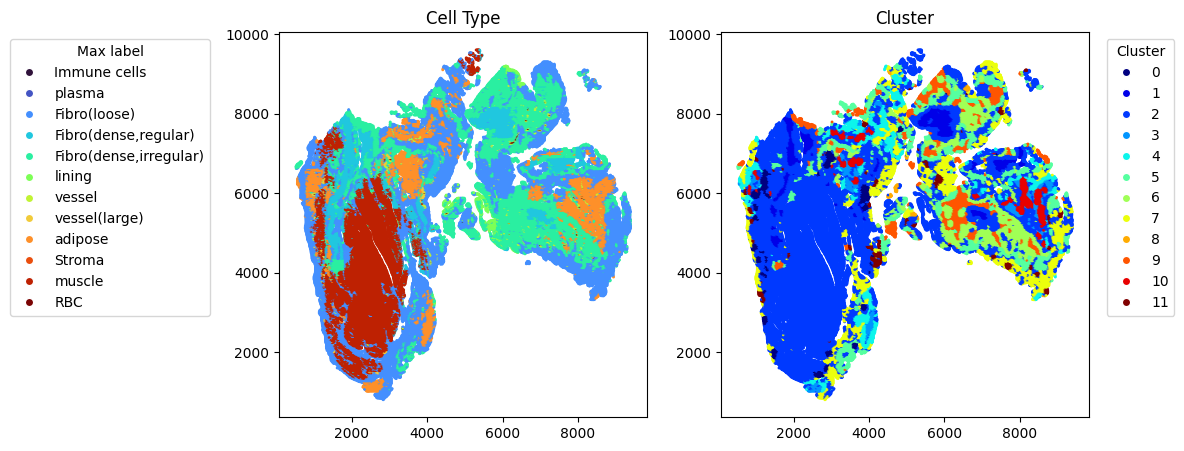

In [14]:
sample = "D130"

plot_cluster(
    sample_info_dict=info_dict[sample],
    num_cluster=num_cluster,
    celltype_cmap="turbo",
    className=className
)

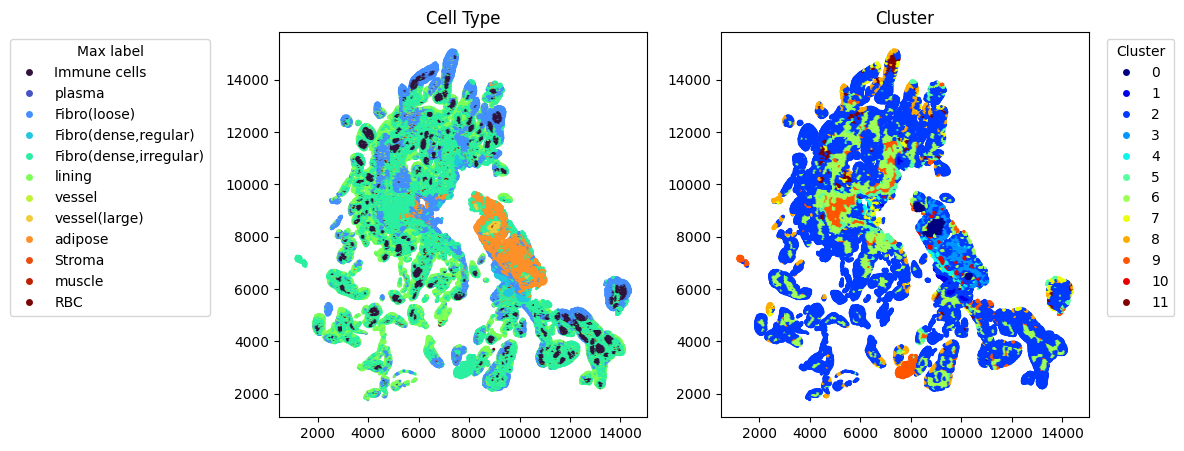

In [15]:
sample = "D001"

plot_cluster(
    sample_info_dict=info_dict[sample],
    num_cluster=num_cluster,
    celltype_cmap="turbo",
    className=className
)

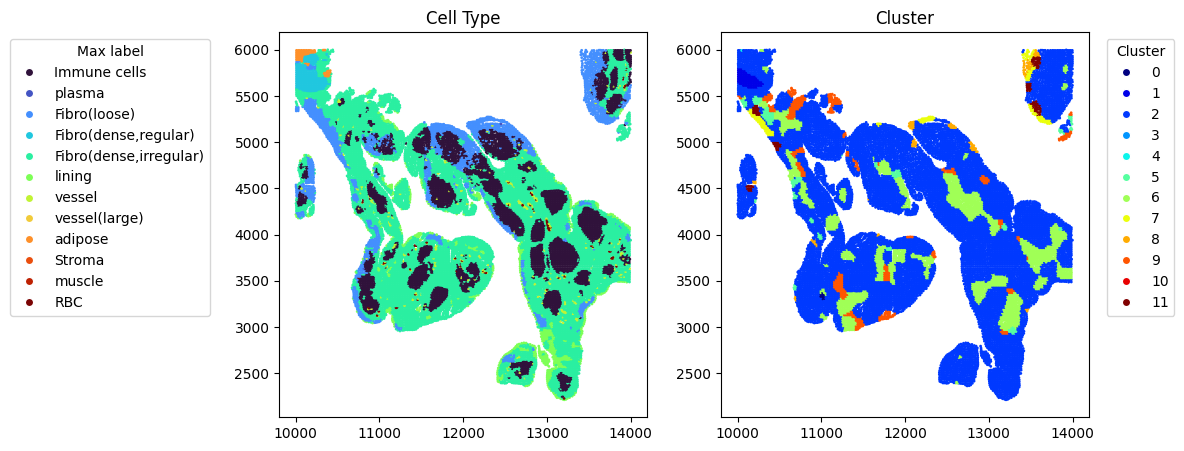

In [16]:
sample = "D001"

plot_cluster(
    sample_info_dict=info_dict[sample],
    num_cluster=num_cluster,
    xmin=10000,xmax=14000,
    ymin=2000,ymax=6000,
    celltype_cmap="turbo",
    className=className
)

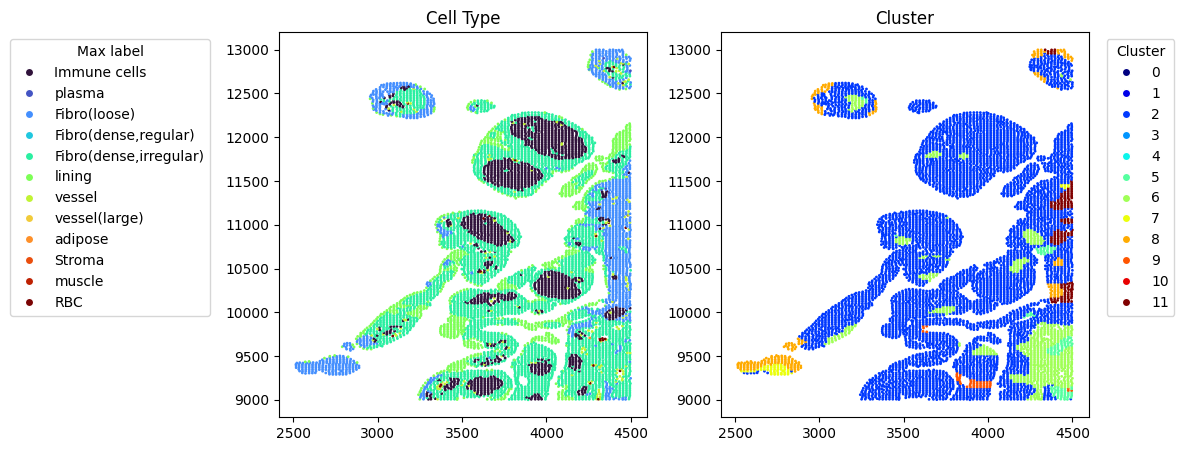

In [17]:
sample = "D001"

plot_cluster(
    sample_info_dict=info_dict[sample], 
    num_cluster=num_cluster,
    xmin=2500,xmax=4500,
    ymin=9000,ymax=13000,
    celltype_cmap="turbo",
    className=className
)

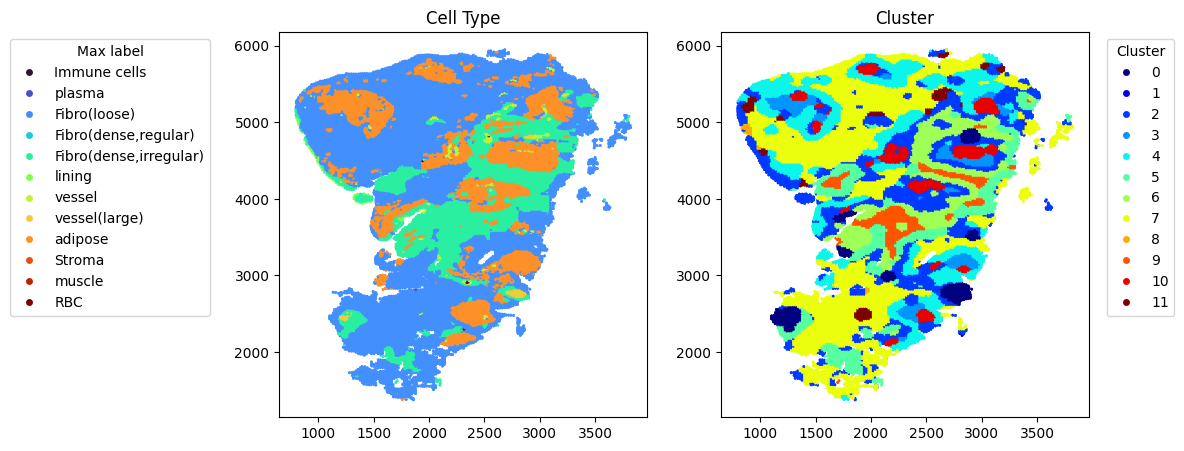

In [18]:
sample = "D002"

plot_cluster(
    sample_info_dict=info_dict[sample],
    num_cluster=num_cluster,
    celltype_cmap="turbo",
    className=className
)

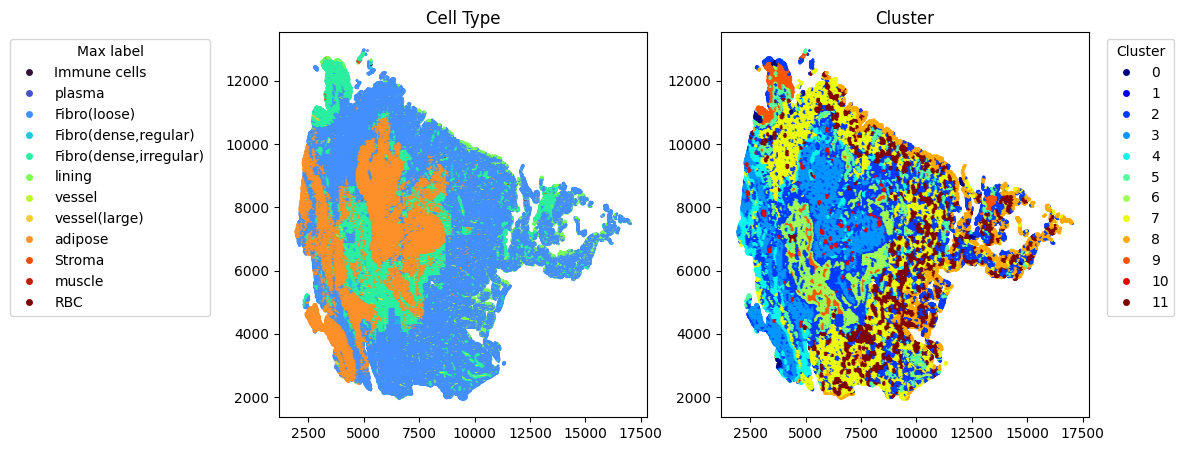

In [19]:
sample = "D003"

plot_cluster(
    sample_info_dict=info_dict[sample],
    num_cluster=num_cluster,
    celltype_cmap="turbo",
    className=className
)

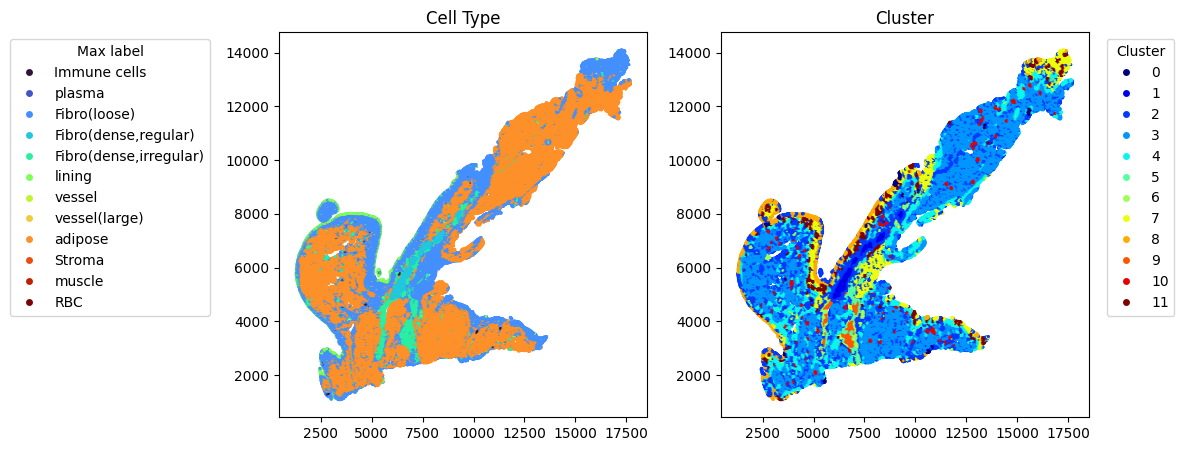

In [20]:
sample = "D004"

plot_cluster(
    sample_info_dict=info_dict[sample], 
    num_cluster=num_cluster,
    celltype_cmap="turbo",
    className=className
)

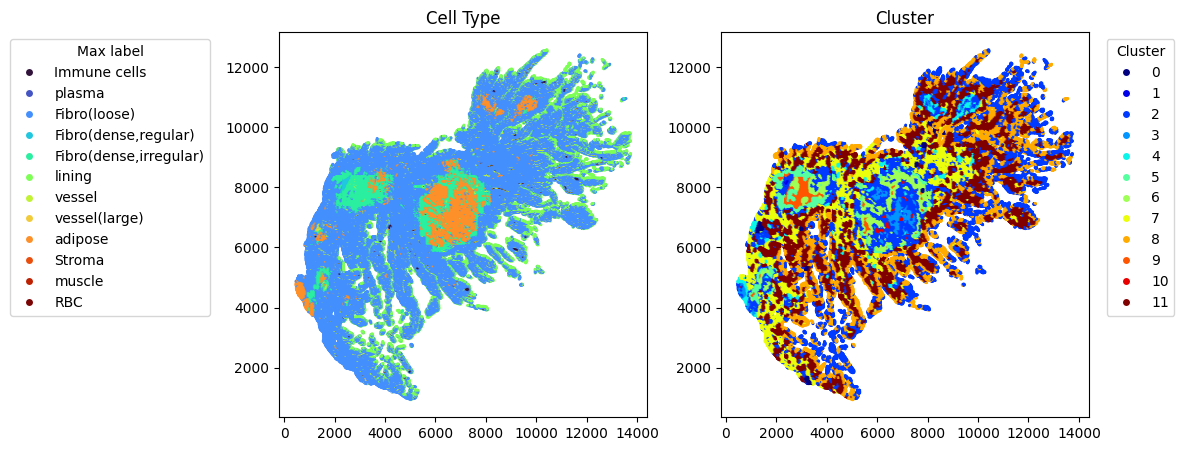

In [21]:
sample = "D005"

plot_cluster(
    sample_info_dict=info_dict[sample],
    num_cluster=num_cluster,
    celltype_cmap="turbo",
    className=className
)

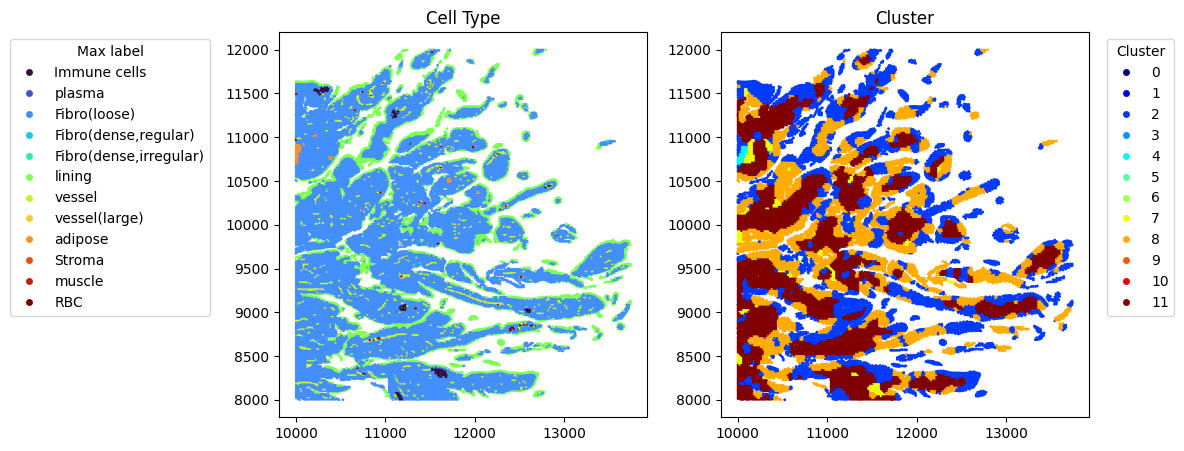

In [22]:
sample = "D005"

plot_cluster(
    sample_info_dict=info_dict[sample],
    num_cluster=num_cluster,
    xmin=10000,xmax=14000,
    ymin=8000,ymax=12000,
    celltype_cmap="turbo",
    className=className
)

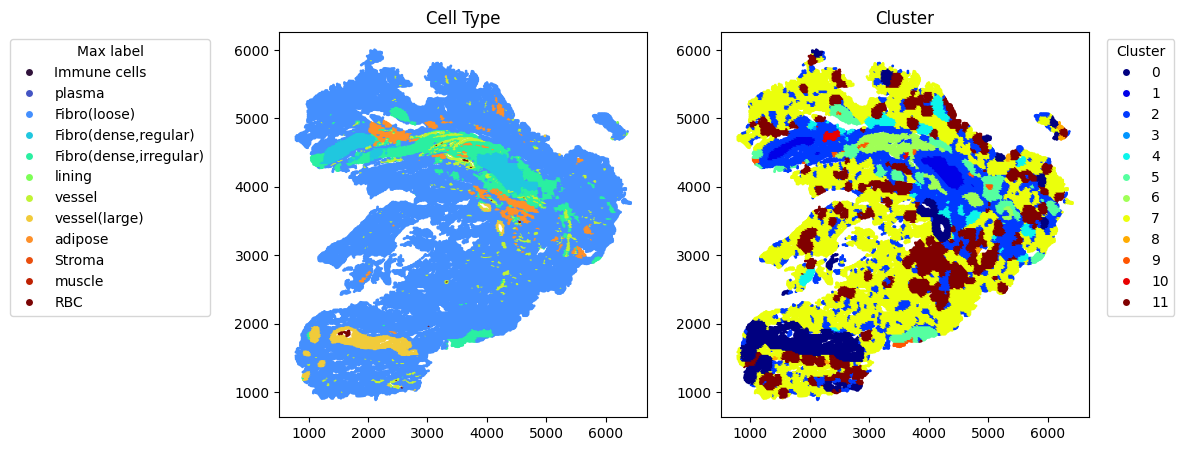

In [23]:
sample = "D006"

plot_cluster(
    sample_info_dict=info_dict[sample],
    num_cluster=num_cluster,
    celltype_cmap="turbo",
    className=className
)

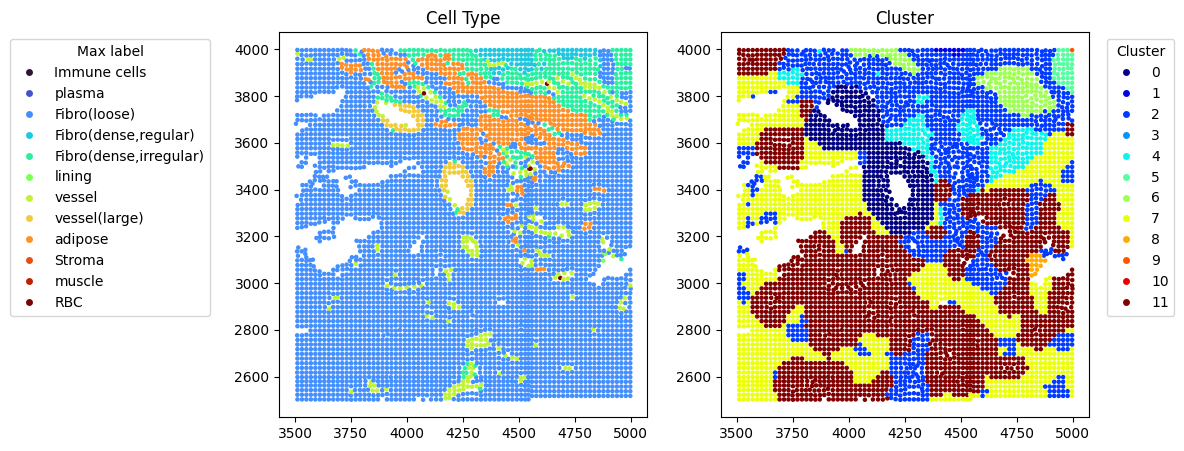

In [24]:
sample = "D006"

plot_cluster(
    sample_info_dict=info_dict[sample],
    num_cluster=num_cluster,
    xmin=3500,xmax=5000,
    ymin=2500,ymax=4000,
    pt_size=5,
    celltype_cmap="turbo",
    className=className
)

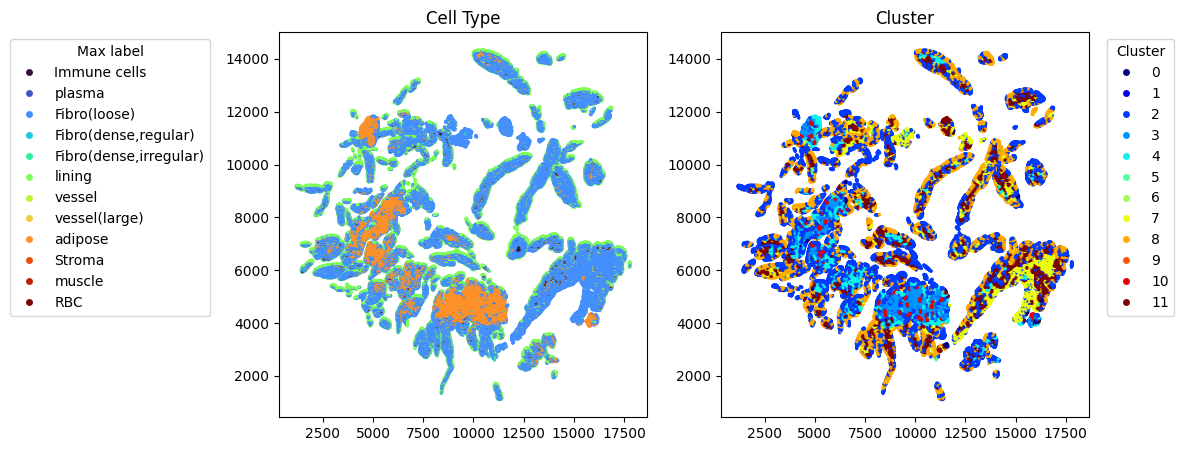

In [25]:
sample = "D007"

plot_cluster(
    sample_info_dict=info_dict[sample], 
    num_cluster=num_cluster,
    celltype_cmap="turbo",
    className=className
)

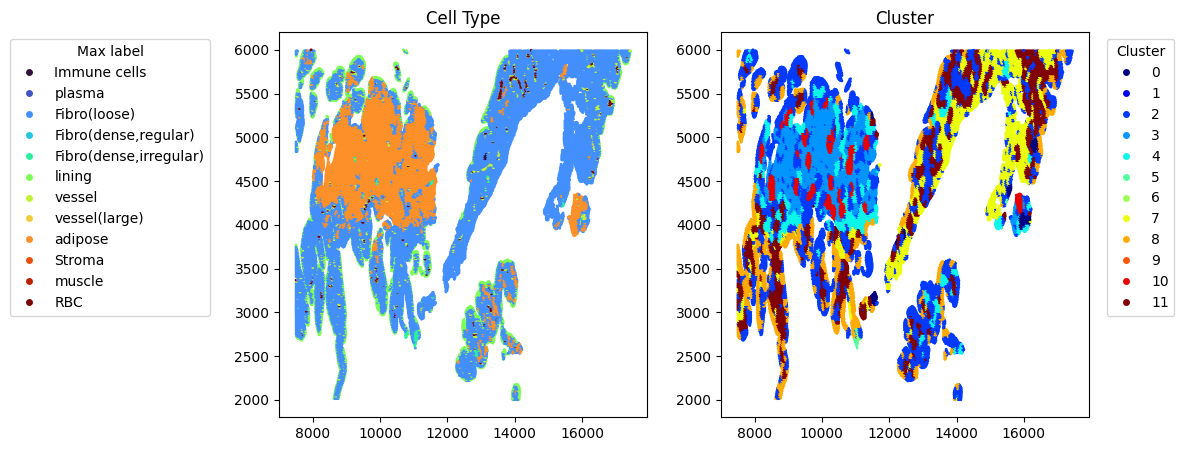

In [26]:
sample = "D007"

plot_cluster(
    sample_info_dict=info_dict[sample],
    num_cluster=num_cluster,
    xmin=7500,xmax=125000,
    ymin=2000,ymax=6000,
    celltype_cmap="turbo",
    className=className
)

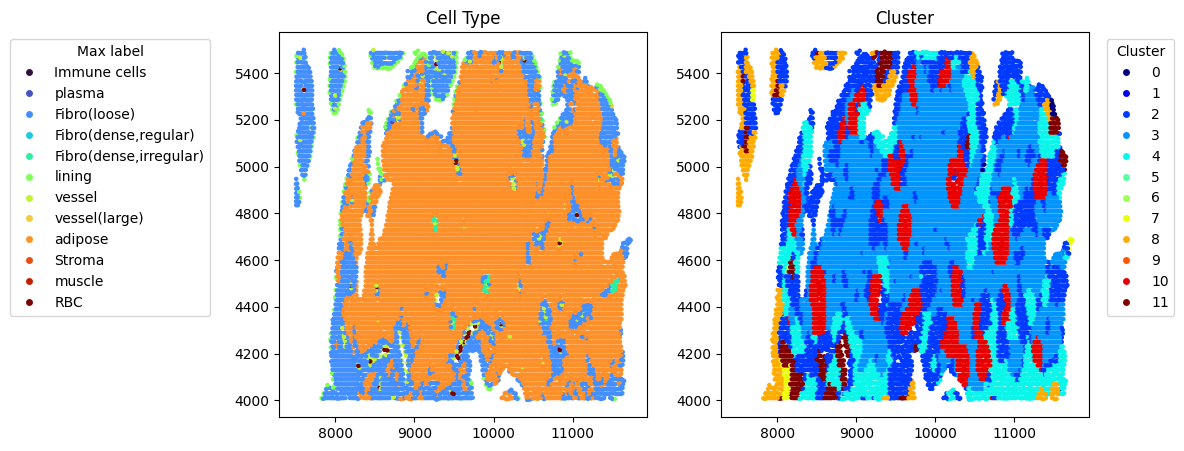

In [27]:
sample = "D007"

plot_cluster(
    sample_info_dict=info_dict[sample],
    num_cluster=num_cluster,
    xmin=7500,xmax=12000,
    ymin=4000,ymax=5500,
    pt_size=5,
    celltype_cmap="turbo",
    className=className
)

## クラスター内の組織割合を集計

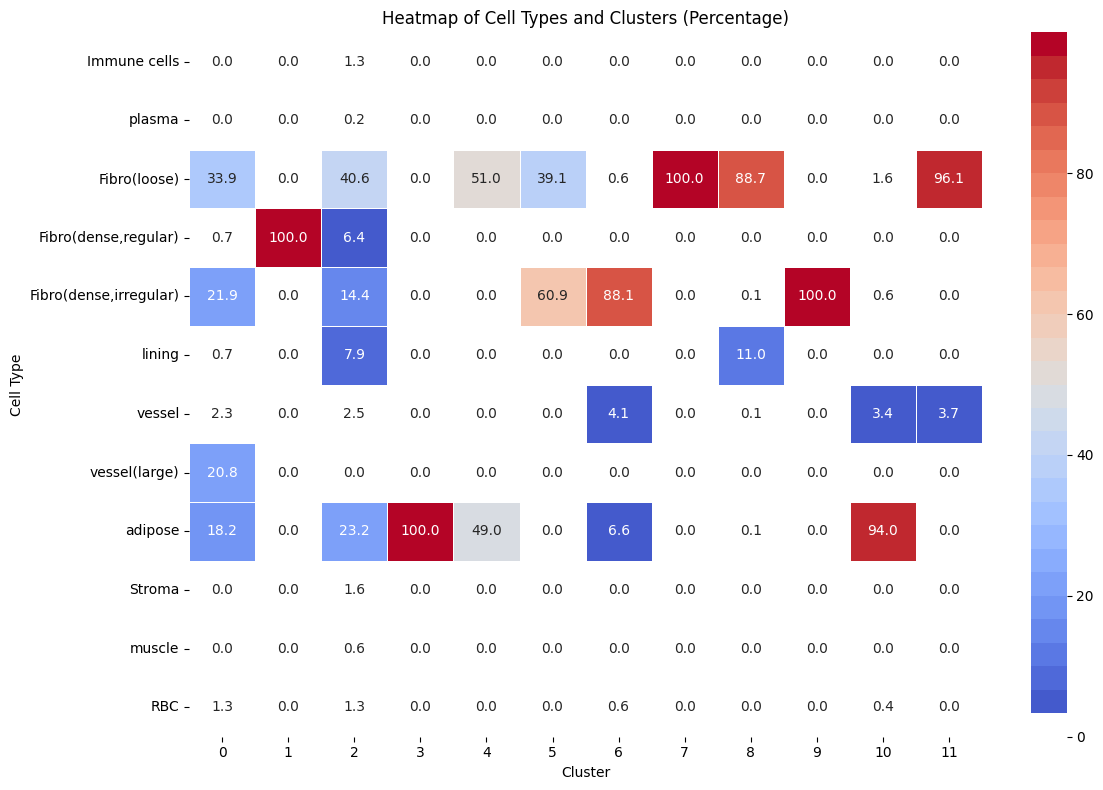

In [28]:
df_ratio_list = []

for donor, value in info_dict.items():
    input_df = value["input_df"]

    # 各行の合計を計算
    row_sums = input_df.sum(axis=1)
    # 各行をその合計で割る
    df_ratio = input_df.div(row_sums, axis=0)

    df_ratio["cluster"] = info_dict[donor]["Cluster"]

    df_ratio_list.append(df_ratio)

df_ratio_merge = pd.concat(df_ratio_list)
df_ratio_merge_mean = df_ratio_merge.groupby("cluster").mean() * 100


className = ["Immune cells", "plasma", "Fibro(loose)", "Fibro(dense,regular)",
"Fibro(dense,irregular)", "lining", "vessel", "vessel(large)",
"adipose", "Stroma", "muscle", "RBC"]

df_ratio_merge_mean.columns = className

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ベースとなるカラーマップを作成
base_cmap = sns.color_palette("coolwarm", as_cmap=True)

# 10段階の色を取得
n_colors = 30
colors = [base_cmap(i / (n_colors - 1)) for i in range(n_colors)]
# 先頭に白を入れる
colors = ["white"] + colors[1:]
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors, N=30)

# ヒートマップの作成
plt.figure(figsize=(12, 8))
sns.heatmap(df_ratio_merge_mean.T, annot=True, fmt='.1f', cmap=cmap, linewidths=0.5)
plt.title('Heatmap of Cell Types and Clusters (Percentage)')
plt.xlabel('Cluster')
plt.ylabel('Cell Type')
plt.tight_layout()
plt.savefig("plots/014_GNN_Kmeans1st_12.pdf")
plt.show()

## コミュニティレベルで集計

In [80]:
def get_community_labels(
    data,
    num_neighbors,
    num_workers=1
):
    from torch_geometric.loader import NeighborLoader

    # dataloaderのインスタンス作成 batch sizeは1でshuffleは無し
    loader = NeighborLoader(
        data, 
        num_neighbors=num_neighbors,
        shuffle=False,
        num_workers=num_workers
    )
    
    ratio_list = [] # 結果の入れ先
    # 1コミュニティずつ取り出して、コミュニティ内ノードのラベルを集計
    for commun in tqdm(loader):
        # コミュニティ内のノードID
        n_id = commun["n_id"]
        # ノード特徴行列からコミュニティノードの箇所だけ抽出
        x = data.x[n_id]
        # コミュニティ内のラベル割合に変換
        ratio = torch.sum(x, dim=0) / torch.sum(x)
        # 結果リストに追記
        ratio_list.append(list(ratio.numpy()))

    # DataFrameに変換 ノード数*ラベル数の行列
    ratio_df = pd.DataFrame(ratio_list)

    return ratio_df

In [81]:
sampling = -1
num_layers = 5

with h5py.File("GNN_InOut.h5", mode="a") as f:
    donors = list(f.keys())
    for donor in tqdm(donors):
        edge_index = f[donor]["edge_index"]
        features = f[donor]["input_feat"]

        # Datasetの中身にアクセス（[:]）
        x = torch.from_numpy(features[:]).to(torch.float32)
        edge_index = torch.from_numpy(edge_index[:]).to(torch.long)

        # Dataインスタンス作成
        data = Data(x=x, edge_index=edge_index.t().contiguous(), donor=donor)

        ratio_df = get_community_labels(
            data=data,
            num_neighbors=[sampling]*num_layers,
            num_workers=1
            )

        # hdf5に書き込み
        f[donor].create_dataset("community_label_ratio", data=ratio_df, compression = "gzip")

  0%|          | 0/118 [00:00<?, ?it/s]


NameError: name 'torch' is not defined

100%|██████████| 118/118 [00:08<00:00, 13.30it/s]


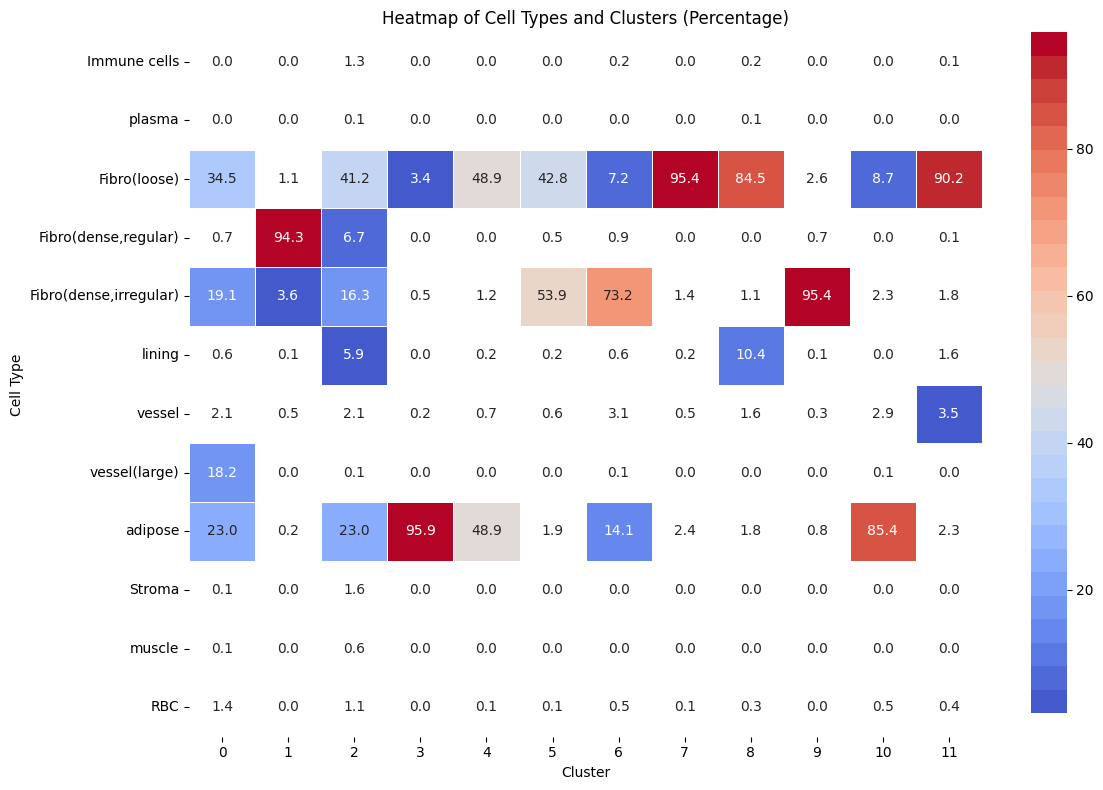

In [29]:
df_ratio_list = []

with h5py.File("GNN_InOut.h5", mode="r") as f:
    donors = list(f.keys())
    for donor in tqdm(donors):
        ratio = f[donor]["community_label_ratio"][:]
        idx = f[donor]["index"][:].astype(str)
        df = pd.DataFrame(ratio, index=idx)

        # 各行の合計を計算
        row_sums = df.sum(axis=1)
        # 各行をその合計で割る
        df_ratio = df.div(row_sums, axis=0)
        df_ratio["cluster"] = info_dict[donor]["Cluster"]

        df_ratio_list.append(df_ratio)

df_ratio_merge = pd.concat(df_ratio_list)

df_ratio_merge_mean = df_ratio_merge.groupby("cluster").mean() * 100

className = ["Immune cells", "plasma", "Fibro(loose)", "Fibro(dense,regular)",
"Fibro(dense,irregular)", "lining", "vessel", "vessel(large)",
"adipose", "Stroma", "muscle", "RBC"]

df_ratio_merge_mean.columns = className


import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ベースとなるカラーマップを作成
base_cmap = sns.color_palette("coolwarm", as_cmap=True)

# 10段階の色を取得
n_colors = 30
colors = [base_cmap(i / (n_colors - 1)) for i in range(n_colors)]
# 先頭に白を入れる
colors = ["white"] + colors[1:]
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors, N=30)

# ヒートマップの作成
plt.figure(figsize=(12, 8))
sns.heatmap(df_ratio_merge_mean.T, annot=True, fmt='.1f', cmap=cmap, linewidths=0.5)
plt.title('Heatmap of Cell Types and Clusters (Percentage)')
plt.xlabel('Cluster')
plt.ylabel('Cell Type')
plt.tight_layout()
plt.savefig("plots/015_GNN_Kmeans1st_12_2.pdf")
plt.show()

## Homo communityの採用

In [30]:
adapt_clusters = [1,3,7,9]
adapt_name = {
    1: "Homo_Fibro(dense,regular)",
    3: "Homo_Adipose",
    7: "Homo_Fibro(loose)",
    9: "Homo_Fibro(dense,irregular)"
}

for patient in patients:
    # 特徴量行列を複製 Result2としてinfo_dictに保存
    info_dict[patient]['Result2'] = pd.DataFrame(
        info_dict[patient]['features']).copy()

    # 1症例のindexを取得
    idx = info_dict[patient]["index"]

    # 現在のcluster番号を取得
    kmeans_cluster = info_dict[patient]["Cluster"]

    # 採用clusterを1つずつ処理
    for adapt_cluster in adapt_clusters:
        # 採用clusterを持つ細胞のindex取得
        ids = idx[kmeans_cluster == adapt_cluster]
        # 採用clusterを持つ細胞のクラスター名をid_clusterに登録
        for id in ids:
            info_dict[patient]["id_cluster"][id] = adapt_name[adapt_cluster]
        # モデル出力の特徴量行列からクラスター確定された細胞を除く
        info_dict[patient]['Result2'].drop(index=ids, inplace=True)


In [31]:
info_dict["D002"]["id_cluster"]

{'5c9f33b1-d224-4e53-900c-9339c6b75b2d': None,
 '9d5e7de3-0be5-45d5-beb5-ab8a825bd1c9': None,
 'e4cdbe18-9418-4470-b90a-55e04f491c65': None,
 'ba77f505-9e74-4936-849d-e5b7ffcd3236': None,
 'f147c9e9-09de-4dba-bed1-893e269121e6': None,
 'ae6c42f6-47c0-4155-a089-f8641f277c89': None,
 '3c8843a8-dc9e-46f7-a9f1-046ca32c7682': 'Homo_Fibro(loose)',
 '1820c913-42e2-49d2-a882-a66494d5b6ae': 'Homo_Fibro(loose)',
 '71bb90dd-071c-4145-81a9-7b8ec3b58e41': None,
 '9690c19c-433c-4255-b02b-d2474775fdb0': None,
 '0f8743ea-a2da-40d9-9b4a-deb0f3a62296': 'Homo_Fibro(loose)',
 '46237421-e54e-43df-9d13-c5de56838099': 'Homo_Fibro(loose)',
 '8c4a393e-822d-474c-bb8f-5e38c2e3483e': None,
 'c3b17dfb-ff95-4934-91aa-0d2c8f998d06': 'Homo_Fibro(loose)',
 '545b0776-445b-4cb4-b482-bfe01adc0e74': 'Homo_Fibro(loose)',
 'c9411ad9-a4f0-4b33-be0e-ab69a659d0c0': 'Homo_Fibro(loose)',
 'dc490add-c53b-4416-8cc7-7e2fb12778df': 'Homo_Fibro(loose)',
 'd05306cb-d51f-4e81-a687-ccc89ed6a1a8': 'Homo_Fibro(loose)',
 '72965fbf-f10d-4e0

## クラスタリング2回目 未アノテーションのtileだけで再クラスタリング

### 12

In [32]:
results = []

for key, value in info_dict.items():
    results.append(value["Result2"])

import sklearn.cluster as cluster

num_cluster = 12

kmeans = cluster.KMeans(n_clusters=num_cluster, random_state=42)
# 症例ごとの結果を結合してK-meansのfitに渡す
print(np.concatenate(results).shape)
kmeans.fit(np.concatenate(results))

(8283118, 64)


KMeans(n_clusters=12, random_state=42)

In [33]:
for patient, value in info_dict.items():
    info_dict[patient]["Cluster2_12"] = kmeans.predict(value["Result2"])

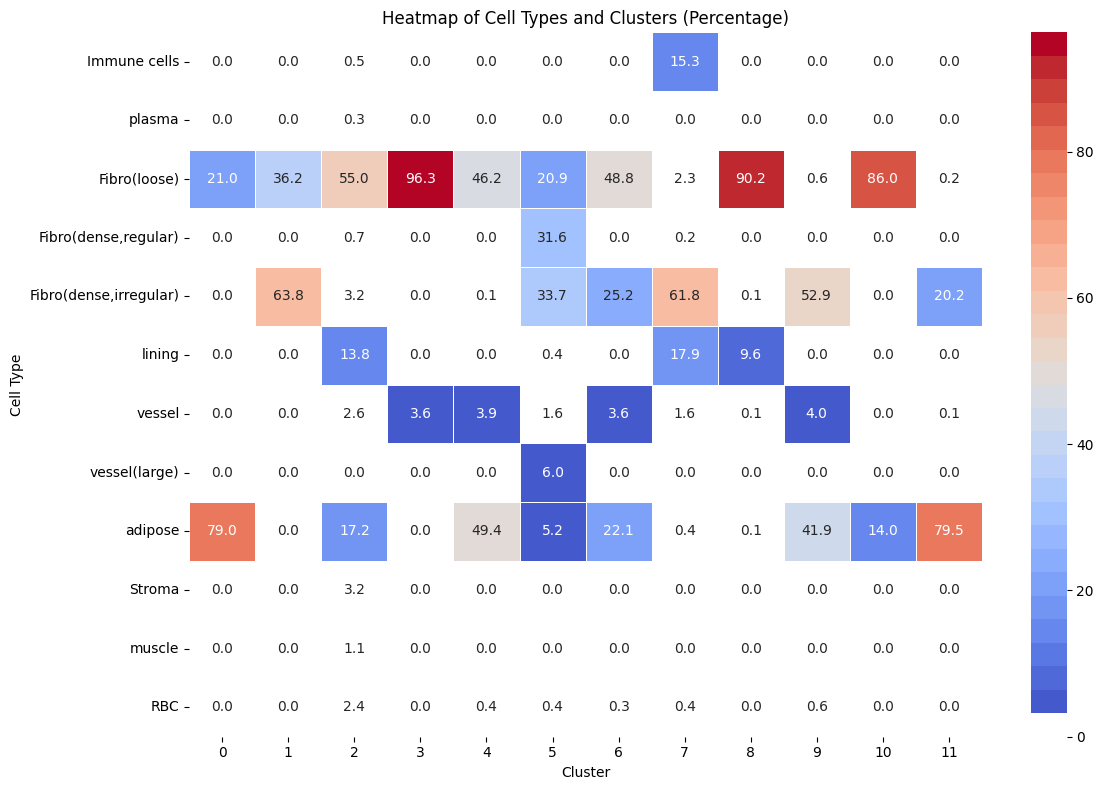

In [34]:
df_ratio_list = []

for patient in patients:
    df = info_dict[patient]["input_df"]
    df2 = df.loc[info_dict[patient]["Result2"].index]
    # 各行の合計を計算
    row_sums = df2.sum(axis=1)
    # 各行をその合計で割る
    df_ratio = df2.div(row_sums, axis=0)
    
    df_ratio["cluster"] = info_dict[patient]["Cluster2_12"]

    df_ratio_list.append(df_ratio)


df_ratio_merge = pd.concat(df_ratio_list)

df_ratio_merge_mean = df_ratio_merge.groupby("cluster").mean() * 100

className = ["Immune cells", "plasma", "Fibro(loose)", "Fibro(dense,regular)",
"Fibro(dense,irregular)",  "lining", "vessel", "vessel(large)",
"adipose", "Stroma", "muscle", "RBC"]

df_ratio_merge_mean.columns = className


import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ベースとなるカラーマップを作成
base_cmap = sns.color_palette("coolwarm", as_cmap=True)

# 10段階の色を取得
n_colors = 30
colors = [base_cmap(i / (n_colors - 1)) for i in range(n_colors)]
# 先頭に白を入れる
colors = ["white"] + colors[1:]
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors, N=30)

# ヒートマップの作成
plt.figure(figsize=(12, 8))
sns.heatmap(df_ratio_merge_mean.T, annot=True, fmt='.1f', cmap=cmap, linewidths=0.5)
plt.title('Heatmap of Cell Types and Clusters (Percentage)')
plt.xlabel('Cluster')
plt.ylabel('Cell Type')
plt.tight_layout()
plt.savefig("plots/016_GNN_Kmeans2nd_12.pdf")
plt.show()

100%|██████████| 118/118 [00:12<00:00,  9.35it/s]


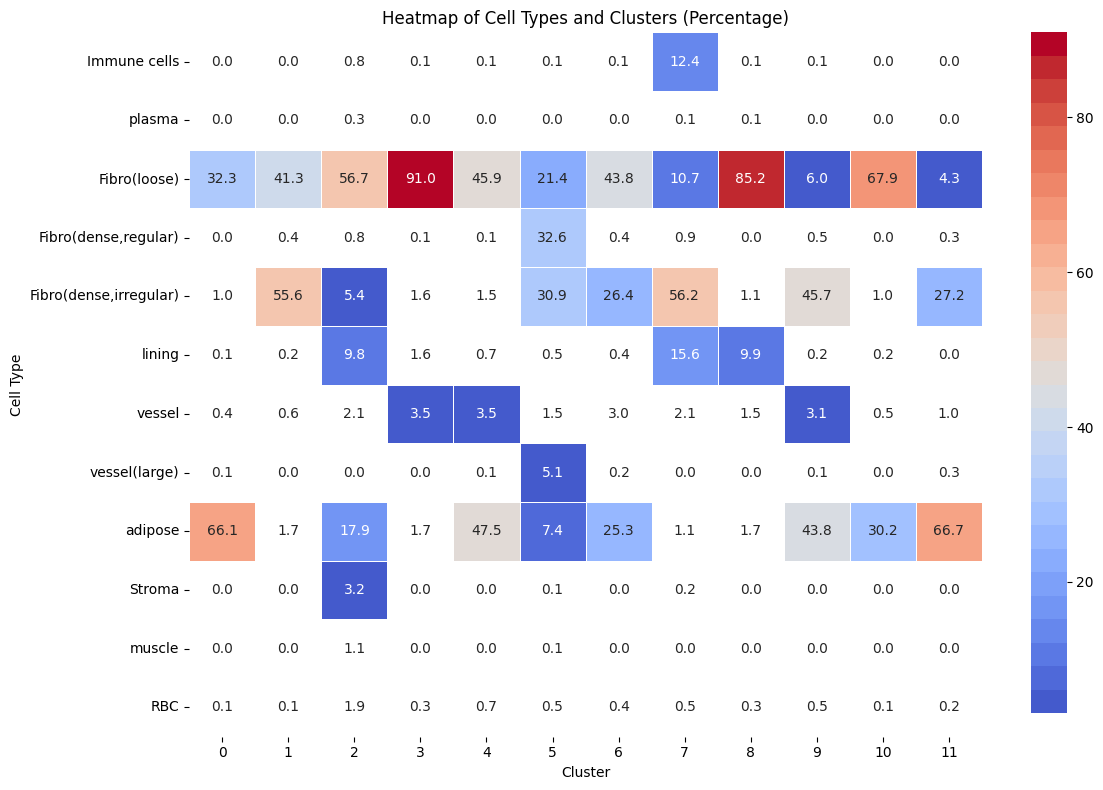

In [35]:
## 5 hop community版

df_ratio_list = []

with h5py.File("GNN_InOut.h5", mode="r") as f:
    patients = list(f.keys())
    for patient in tqdm(patients):
        ratio = f[patient]["community_label_ratio"][:]
        idx = f[patient]["index"][:].astype(str)
        df = pd.DataFrame(ratio, index=idx)
        df2 = df.loc[info_dict[patient]["Result2"].index]

        # 各行の合計を計算
        row_sums = df2.sum(axis=1)
        # 各行をその合計で割る
        df_ratio = df2.div(row_sums, axis=0)
        df_ratio["cluster"] = info_dict[patient]["Cluster2_12"]

        df_ratio_list.append(df_ratio)



df_ratio_merge = pd.concat(df_ratio_list)

df_ratio_merge_mean = df_ratio_merge.groupby("cluster").mean() * 100

className = ["Immune cells", "plasma", "Fibro(loose)", "Fibro(dense,regular)",
"Fibro(dense,irregular)", "lining", "vessel", "vessel(large)",
"adipose", "Stroma", "muscle", "RBC"]

df_ratio_merge_mean.columns = className


import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ベースとなるカラーマップを作成
base_cmap = sns.color_palette("coolwarm", as_cmap=True)

# 10段階の色を取得
n_colors = 30
colors = [base_cmap(i / (n_colors - 1)) for i in range(n_colors)]
# 先頭に白を入れる
colors = ["white"] + colors[1:]
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors, N=30)

# ヒートマップの作成
plt.figure(figsize=(12, 8))
sns.heatmap(df_ratio_merge_mean.T, annot=True, fmt='.1f', cmap=cmap, linewidths=0.5)
plt.title('Heatmap of Cell Types and Clusters (Percentage)')
plt.xlabel('Cluster')
plt.ylabel('Cell Type')
plt.tight_layout()
plt.savefig("plots/017_GNN_Kmeans2nd_12_2.pdf")
plt.show()

### 15

In [36]:
results = []

for key, value in info_dict.items():
    results.append(value["Result2"])

import sklearn.cluster as cluster

num_cluster = 15

kmeans = cluster.KMeans(n_clusters=num_cluster, random_state=42)
# 症例ごとの結果を結合してK-meansのfitに渡す
print(np.concatenate(results).shape)
kmeans.fit(np.concatenate(results))

(8283118, 64)


KMeans(n_clusters=15, random_state=42)

In [37]:
for patient, value in info_dict.items():
    info_dict[patient]["Cluster2_15"] = kmeans.predict(value["Result2"])

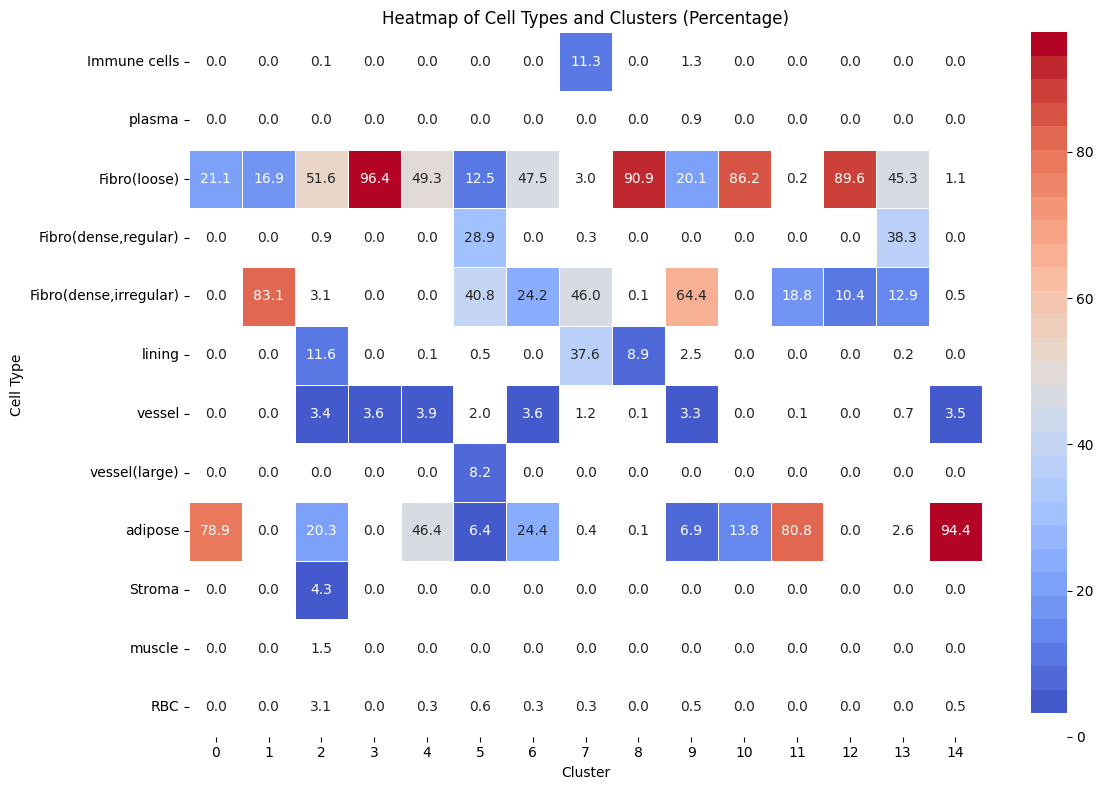

In [38]:
df_ratio_list = []

for patient in patients:
    df = info_dict[patient]["input_df"]
    df2 = df.loc[info_dict[patient]["Result2"].index]
    # 各行の合計を計算
    row_sums = df2.sum(axis=1)
    # 各行をその合計で割る
    df_ratio = df2.div(row_sums, axis=0)
    
    df_ratio["cluster"] = info_dict[patient]["Cluster2_15"]

    df_ratio_list.append(df_ratio)


df_ratio_merge = pd.concat(df_ratio_list)

df_ratio_merge_mean = df_ratio_merge.groupby("cluster").mean() * 100

className = ["Immune cells", "plasma", "Fibro(loose)", "Fibro(dense,regular)",
"Fibro(dense,irregular)",  "lining", "vessel", "vessel(large)",
"adipose", "Stroma", "muscle", "RBC"]

df_ratio_merge_mean.columns = className


import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ベースとなるカラーマップを作成
base_cmap = sns.color_palette("coolwarm", as_cmap=True)

# 10段階の色を取得
n_colors = 30
colors = [base_cmap(i / (n_colors - 1)) for i in range(n_colors)]
# 先頭に白を入れる
colors = ["white"] + colors[1:]
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors, N=30)

# ヒートマップの作成
plt.figure(figsize=(12, 8))
sns.heatmap(df_ratio_merge_mean.T, annot=True, fmt='.1f', cmap=cmap, linewidths=0.5)
plt.title('Heatmap of Cell Types and Clusters (Percentage)')
plt.xlabel('Cluster')
plt.ylabel('Cell Type')
plt.tight_layout()
plt.savefig("plots/018_GNN_Kmeans2nd_15.pdf")
plt.show()

100%|██████████| 118/118 [00:13<00:00,  8.64it/s]


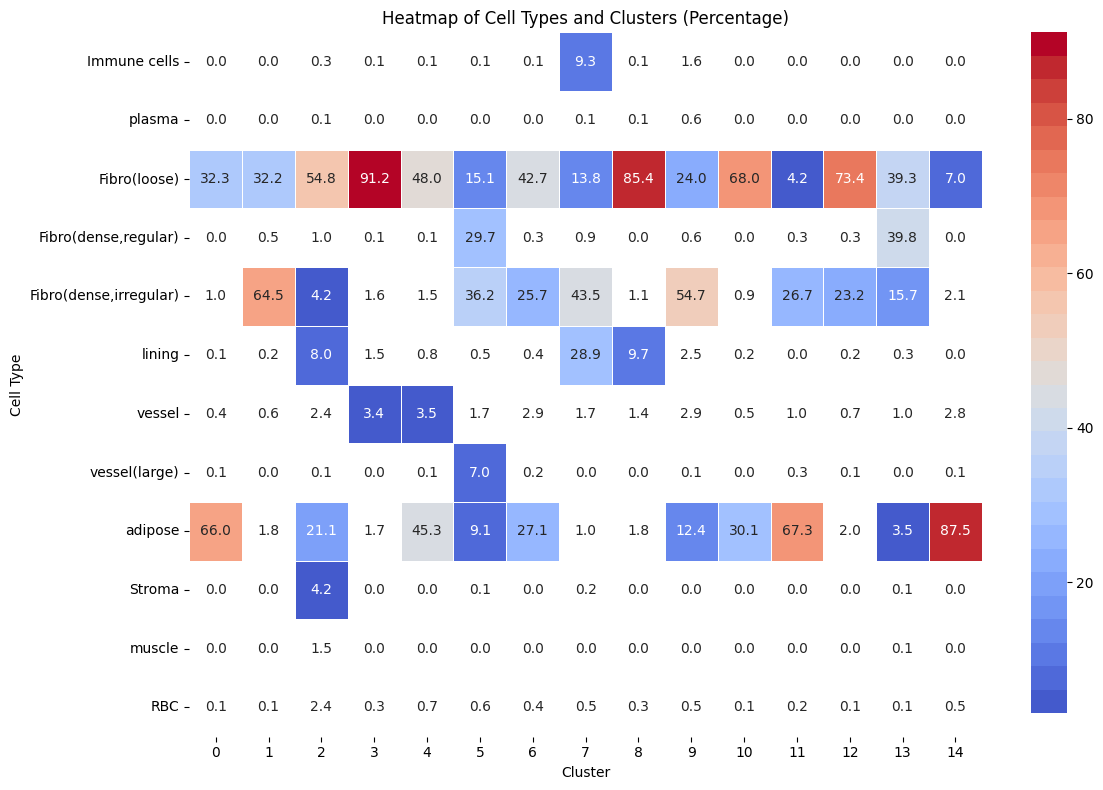

In [39]:
## 5 hop community版

df_ratio_list = []

with h5py.File("GNN_InOut.h5", mode="r") as f:
    patients = list(f.keys())
    for patient in tqdm(patients):
        ratio = f[patient]["community_label_ratio"][:]
        idx = f[patient]["index"][:].astype(str)
        df = pd.DataFrame(ratio, index=idx)
        df2 = df.loc[info_dict[patient]["Result2"].index]

        # 各行の合計を計算
        row_sums = df2.sum(axis=1)
        # 各行をその合計で割る
        df_ratio = df2.div(row_sums, axis=0)
        df_ratio["cluster"] = info_dict[patient]["Cluster2_15"]

        df_ratio_list.append(df_ratio)



df_ratio_merge = pd.concat(df_ratio_list)

df_ratio_merge_mean = df_ratio_merge.groupby("cluster").mean() * 100

className = ["Immune cells", "plasma", "Fibro(loose)", "Fibro(dense,regular)",
"Fibro(dense,irregular)", "lining", "vessel", "vessel(large)",
"adipose", "Stroma", "muscle", "RBC"]

df_ratio_merge_mean.columns = className


import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ベースとなるカラーマップを作成
base_cmap = sns.color_palette("coolwarm", as_cmap=True)

# 10段階の色を取得
n_colors = 30
colors = [base_cmap(i / (n_colors - 1)) for i in range(n_colors)]
# 先頭に白を入れる
colors = ["white"] + colors[1:]
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors, N=30)

# ヒートマップの作成
plt.figure(figsize=(12, 8))
sns.heatmap(df_ratio_merge_mean.T, annot=True, fmt='.1f', cmap=cmap, linewidths=0.5)
plt.title('Heatmap of Cell Types and Clusters (Percentage)')
plt.xlabel('Cluster')
plt.ylabel('Cell Type')
plt.tight_layout()
plt.savefig("plots/019_GNN_Kmeans2nd_15_2.pdf")
plt.show()

In [40]:
adapt_names = {
    0: "Hetero_Adipose-Fibro(loose)",
    1: "Hetero_Fibro(loose)-Fibro(dense,irregular)",
    # 2: "Hetero_Lining-Fibro(loose)",
    3: "Hetero_Fibro(loose)-Vessel",
    4: "Hetero_Fibro(loose)-Vessel-Adipose",
    # 5: "Mix_Fibrous-Vessel(large)",
    # 6: "Mix_Fibrous-Vessel-Adipose",
    # 7: "Hetero_Lining-Immune-Fibro(dense,irregular)",
    # 8: "Hetero_Lining-Fibro(loose)",
    9: "Hetero_Fibro(dense,irregular)-Adipose-Vessel",
    10: "Hetero_Fibro(loose)-Adipose",
    11: "Hetero_Fibrous-Vessel-Adipose"
}
adapt_clusters = adapt_names.keys()

for patient in patients:
    # 特徴量行列を複製 Result2としてinfo_dictに保存
    info_dict[patient]['Result3'] = info_dict[patient]['Result2'].copy()

    # 1症例のindexを取得
    idx = info_dict[patient]['Result3'].index

    # 現在のcluster番号を取得
    kmeans_cluster = info_dict[patient]["Cluster2_12"]

    # 採用clusterを1つずつ処理
    for adapt_cluster in adapt_clusters:
        # 採用clusterを持つ細胞のindex取得
        ids = idx[kmeans_cluster == adapt_cluster]
        # 採用clusterを持つ細胞のクラスター名をid_clusterに登録
        for id in ids:
            info_dict[patient]["id_cluster"][id] = adapt_names[adapt_cluster]
        # モデル出力の特徴量行列からクラスター確定された細胞を除く
        info_dict[patient]['Result3'].drop(index=ids, inplace=True)


In [41]:
info_dict["D002"]["id_cluster"]

{'5c9f33b1-d224-4e53-900c-9339c6b75b2d': 'Hetero_Fibro(loose)-Adipose',
 '9d5e7de3-0be5-45d5-beb5-ab8a825bd1c9': 'Hetero_Fibro(loose)-Adipose',
 'e4cdbe18-9418-4470-b90a-55e04f491c65': None,
 'ba77f505-9e74-4936-849d-e5b7ffcd3236': 'Hetero_Fibro(loose)-Adipose',
 'f147c9e9-09de-4dba-bed1-893e269121e6': 'Hetero_Fibro(loose)-Adipose',
 'ae6c42f6-47c0-4155-a089-f8641f277c89': None,
 '3c8843a8-dc9e-46f7-a9f1-046ca32c7682': 'Homo_Fibro(loose)',
 '1820c913-42e2-49d2-a882-a66494d5b6ae': 'Homo_Fibro(loose)',
 '71bb90dd-071c-4145-81a9-7b8ec3b58e41': 'Hetero_Fibro(loose)-Adipose',
 '9690c19c-433c-4255-b02b-d2474775fdb0': 'Hetero_Fibro(loose)-Adipose',
 '0f8743ea-a2da-40d9-9b4a-deb0f3a62296': 'Homo_Fibro(loose)',
 '46237421-e54e-43df-9d13-c5de56838099': 'Homo_Fibro(loose)',
 '8c4a393e-822d-474c-bb8f-5e38c2e3483e': 'Hetero_Fibro(loose)-Adipose',
 'c3b17dfb-ff95-4934-91aa-0d2c8f998d06': 'Homo_Fibro(loose)',
 '545b0776-445b-4cb4-b482-bfe01adc0e74': 'Homo_Fibro(loose)',
 'c9411ad9-a4f0-4b33-be0e-ab69

## クラスタリング 3回目

In [42]:
results = []

for key, value in info_dict.items():
    results.append(value["Result3"])

import sklearn.cluster as cluster

num_cluster = 12

kmeans = cluster.KMeans(n_clusters=num_cluster, random_state=42)
# 症例ごとの結果を結合してK-meansのfitに渡す
print(np.concatenate(results).shape)
kmeans.fit(np.concatenate(results))


(4067012, 64)


KMeans(n_clusters=12, random_state=42)

In [43]:
for patient, value in info_dict.items():
    info_dict[patient]["Cluster3_12"] = kmeans.predict(value["Result3"])


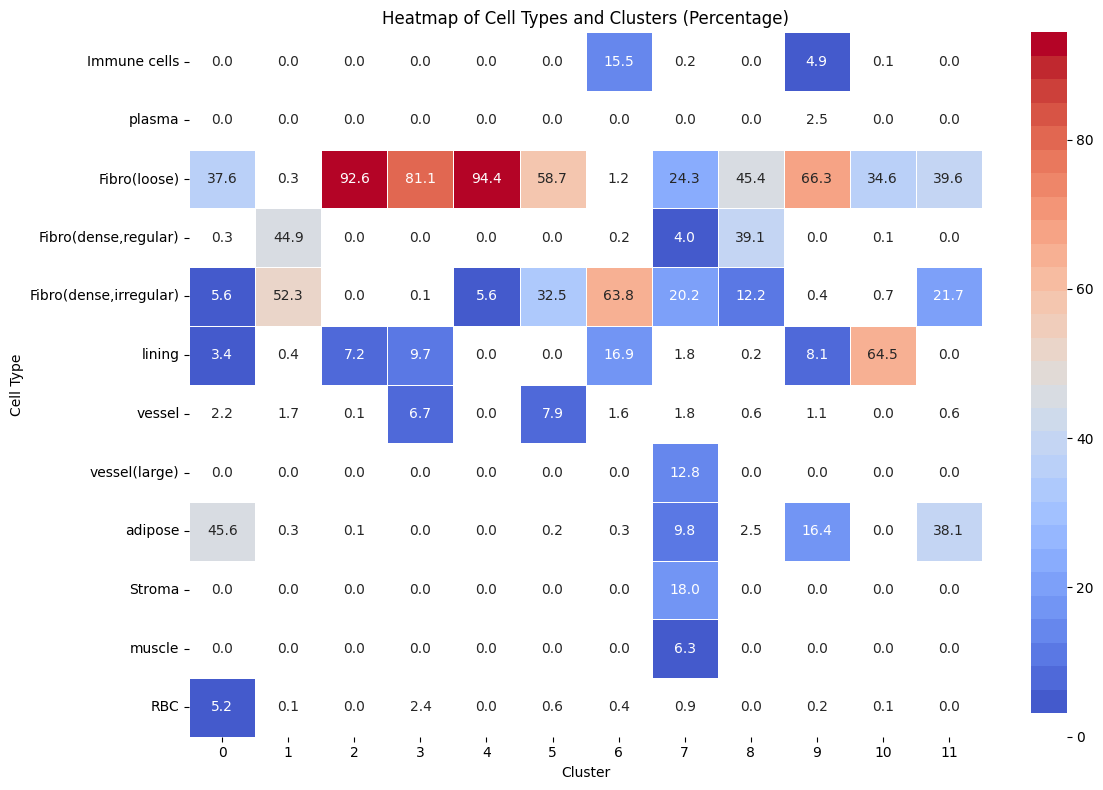

In [44]:
df_ratio_list = []

for patient in patients:
    df = info_dict[patient]["input_df"]
    df2 = df.loc[info_dict[patient]["Result3"].index]
    # 各行の合計を計算
    row_sums = df2.sum(axis=1)
    # 各行をその合計で割る
    df_ratio = df2.div(row_sums, axis=0)
    
    df_ratio["cluster"] = info_dict[patient]["Cluster3_12"]

    df_ratio_list.append(df_ratio)


df_ratio_merge = pd.concat(df_ratio_list)

df_ratio_merge_mean = df_ratio_merge.groupby("cluster").mean() * 100

className = ["Immune cells", "plasma", "Fibro(loose)", "Fibro(dense,regular)",
"Fibro(dense,irregular)",  "lining", "vessel", "vessel(large)",
"adipose", "Stroma", "muscle", "RBC"]

df_ratio_merge_mean.columns = className


import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ベースとなるカラーマップを作成
base_cmap = sns.color_palette("coolwarm", as_cmap=True)

# 10段階の色を取得
n_colors = 30
colors = [base_cmap(i / (n_colors - 1)) for i in range(n_colors)]
# 先頭に白を入れる
colors = ["white"] + colors[1:]
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors, N=30)

# ヒートマップの作成
plt.figure(figsize=(12, 8))
sns.heatmap(df_ratio_merge_mean.T, annot=True, fmt='.1f', cmap=cmap, linewidths=0.5)
plt.title('Heatmap of Cell Types and Clusters (Percentage)')
plt.xlabel('Cluster')
plt.ylabel('Cell Type')
plt.tight_layout()
plt.savefig("plots/020_GNN_Kmeans3rd_12.pdf")
plt.show()


In [45]:
results = []

for key, value in info_dict.items():
    results.append(value["Result3"])

import sklearn.cluster as cluster

num_cluster = 6

kmeans = cluster.KMeans(n_clusters=num_cluster, random_state=42)
# 症例ごとの結果を結合してK-meansのfitに渡す
print(np.concatenate(results).shape)
kmeans.fit(np.concatenate(results))


(4067012, 64)


KMeans(n_clusters=6, random_state=42)

In [46]:
for patient, value in info_dict.items():
    info_dict[patient]["Cluster3_6"] = kmeans.predict(value["Result3"])


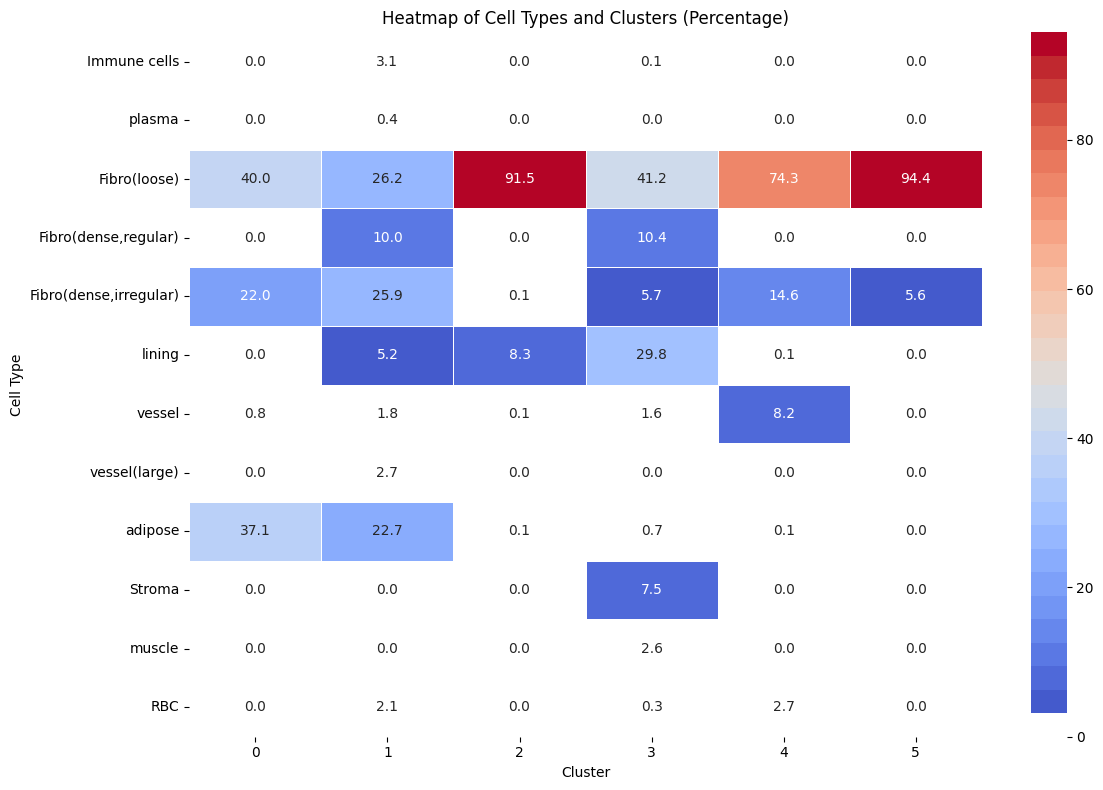

In [47]:
df_ratio_list = []

for patient in patients:
    df = info_dict[patient]["input_df"]
    df2 = df.loc[info_dict[patient]["Result3"].index]
    # 各行の合計を計算
    row_sums = df2.sum(axis=1)
    # 各行をその合計で割る
    df_ratio = df2.div(row_sums, axis=0)

    df_ratio["cluster"] = info_dict[patient]["Cluster3_6"]

    df_ratio_list.append(df_ratio)


df_ratio_merge = pd.concat(df_ratio_list)

df_ratio_merge_mean = df_ratio_merge.groupby("cluster").mean() * 100

className = ["Immune cells", "plasma", "Fibro(loose)", "Fibro(dense,regular)",
"Fibro(dense,irregular)",  "lining", "vessel", "vessel(large)",
"adipose", "Stroma", "muscle", "RBC"]

df_ratio_merge_mean.columns = className


import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ベースとなるカラーマップを作成
base_cmap = sns.color_palette("coolwarm", as_cmap=True)

# 10段階の色を取得
n_colors = 30
colors = [base_cmap(i / (n_colors - 1)) for i in range(n_colors)]
# 先頭に白を入れる
colors = ["white"] + colors[1:]
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors, N=30)

# ヒートマップの作成
plt.figure(figsize=(12, 8))
sns.heatmap(df_ratio_merge_mean.T, annot=True, fmt='.1f', cmap=cmap, linewidths=0.5)
plt.title('Heatmap of Cell Types and Clusters (Percentage)')
plt.xlabel('Cluster')
plt.ylabel('Cell Type')
plt.tight_layout()
plt.savefig("plots/021_GNN_Kmeans3rd_6.pdf")
plt.show()


### k=8

In [48]:
results = []

for key, value in info_dict.items():
    results.append(value["Result3"])

import sklearn.cluster as cluster

num_cluster = 8

kmeans = cluster.KMeans(n_clusters=num_cluster, random_state=42)
# 症例ごとの結果を結合してK-meansのfitに渡す
print(np.concatenate(results).shape)
kmeans.fit(np.concatenate(results))


(4067012, 64)


KMeans(random_state=42)

In [49]:
for patient, value in info_dict.items():
    info_dict[patient]["Cluster3_8"] = kmeans.predict(value["Result3"])


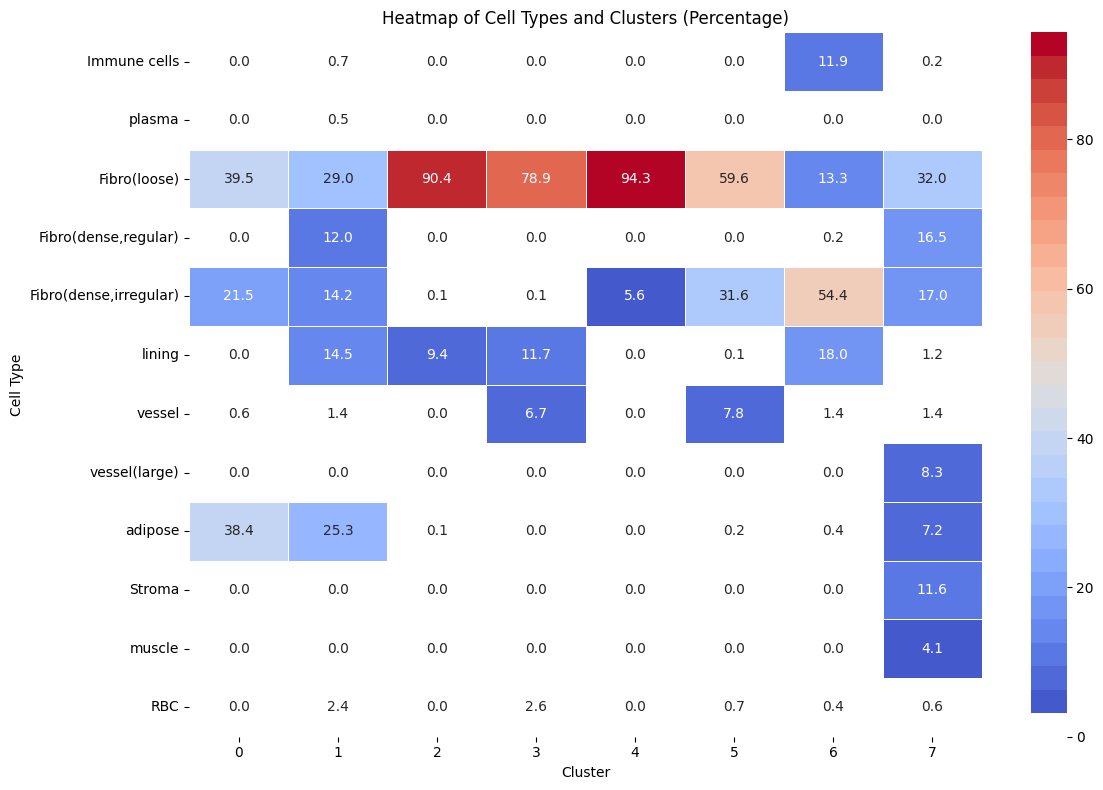

In [55]:
df_ratio_list = []

for patient in patients:
    df = info_dict[patient]["input_df"]
    df2 = df.loc[info_dict[patient]["Result3"].index]
    # 各行の合計を計算
    row_sums = df2.sum(axis=1)
    # 各行をその合計で割る
    df_ratio = df2.div(row_sums, axis=0)

    df_ratio["cluster"] = info_dict[patient]["Cluster3_8"]

    df_ratio_list.append(df_ratio)


df_ratio_merge = pd.concat(df_ratio_list)

df_ratio_merge_mean = df_ratio_merge.groupby("cluster").mean() * 100

className = ["Immune cells", "plasma", "Fibro(loose)", "Fibro(dense,regular)",
"Fibro(dense,irregular)",  "lining", "vessel", "vessel(large)",
"adipose", "Stroma", "muscle", "RBC"]

df_ratio_merge_mean.columns = className


import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ベースとなるカラーマップを作成
base_cmap = sns.color_palette("coolwarm", as_cmap=True)

# 10段階の色を取得
n_colors = 30
colors = [base_cmap(i / (n_colors - 1)) for i in range(n_colors)]
# 先頭に白を入れる
colors = ["white"] + colors[1:]
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors, N=30)

# ヒートマップの作成
plt.figure(figsize=(12, 8))
sns.heatmap(df_ratio_merge_mean.T, annot=True, fmt='.1f', cmap=cmap, linewidths=0.5)
plt.title('Heatmap of Cell Types and Clusters (Percentage)')
plt.xlabel('Cluster')
plt.ylabel('Cell Type')
plt.tight_layout()
plt.savefig("plots/021_GNN_Kmeans3rd_8.pdf")
plt.show()


100%|██████████| 118/118 [00:11<00:00, 10.13it/s]


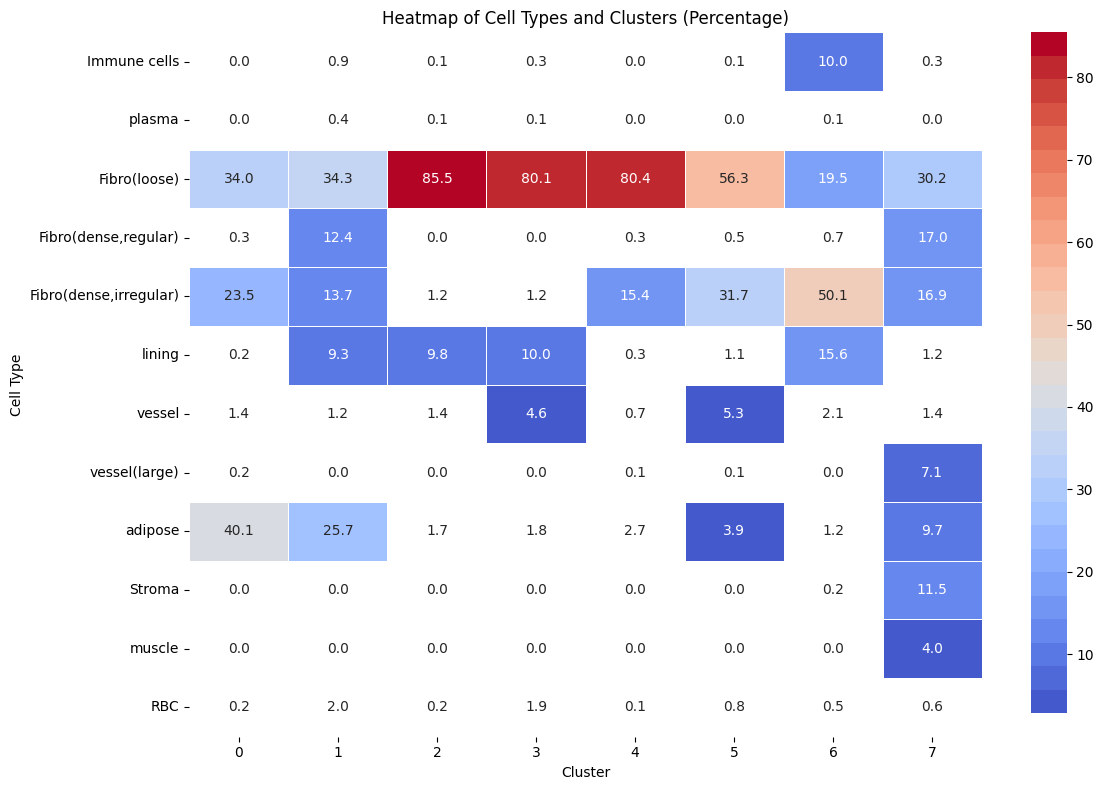

In [51]:
## 5 hop community版

df_ratio_list = []

with h5py.File("GNN_InOut.h5", mode="r") as f:
    patients = list(f.keys())
    for patient in tqdm(patients):
        ratio = f[patient]["community_label_ratio"][:]
        idx = f[patient]["index"][:].astype(str)
        df = pd.DataFrame(ratio, index=idx)
        df2 = df.loc[info_dict[patient]["Result3"].index]

        # 各行の合計を計算
        row_sums = df2.sum(axis=1)
        # 各行をその合計で割る
        df_ratio = df2.div(row_sums, axis=0)
        df_ratio["cluster"] = info_dict[patient]["Cluster3_8"]

        df_ratio_list.append(df_ratio)



df_ratio_merge = pd.concat(df_ratio_list)

df_ratio_merge_mean = df_ratio_merge.groupby("cluster").mean() * 100

className = ["Immune cells", "plasma", "Fibro(loose)", "Fibro(dense,regular)",
"Fibro(dense,irregular)", "lining", "vessel", "vessel(large)",
"adipose", "Stroma", "muscle", "RBC"]

df_ratio_merge_mean.columns = className


import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ベースとなるカラーマップを作成
base_cmap = sns.color_palette("coolwarm", as_cmap=True)

# 10段階の色を取得
n_colors = 30
colors = [base_cmap(i / (n_colors - 1)) for i in range(n_colors)]
# 先頭に白を入れる
colors = ["white"] + colors[1:]
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors, N=30)

# ヒートマップの作成
plt.figure(figsize=(12, 8))
sns.heatmap(df_ratio_merge_mean.T, annot=True, fmt='.1f', cmap=cmap, linewidths=0.5)
plt.title('Heatmap of Cell Types and Clusters (Percentage)')
plt.xlabel('Cluster')
plt.ylabel('Cell Type')
plt.tight_layout()
plt.savefig("plots/022_GNN_Kmeans3rd_8_2.pdf")
plt.show()

### k=10

In [52]:
results = []

for key, value in info_dict.items():
    results.append(value["Result3"])

import sklearn.cluster as cluster

num_cluster = 10

kmeans = cluster.KMeans(n_clusters=num_cluster, random_state=42)
# 症例ごとの結果を結合してK-meansのfitに渡す
print(np.concatenate(results).shape)
kmeans.fit(np.concatenate(results))


(4067012, 64)


KMeans(n_clusters=10, random_state=42)

In [53]:
for patient, value in info_dict.items():
    info_dict[patient]["Cluster3_10"] = kmeans.predict(value["Result3"])


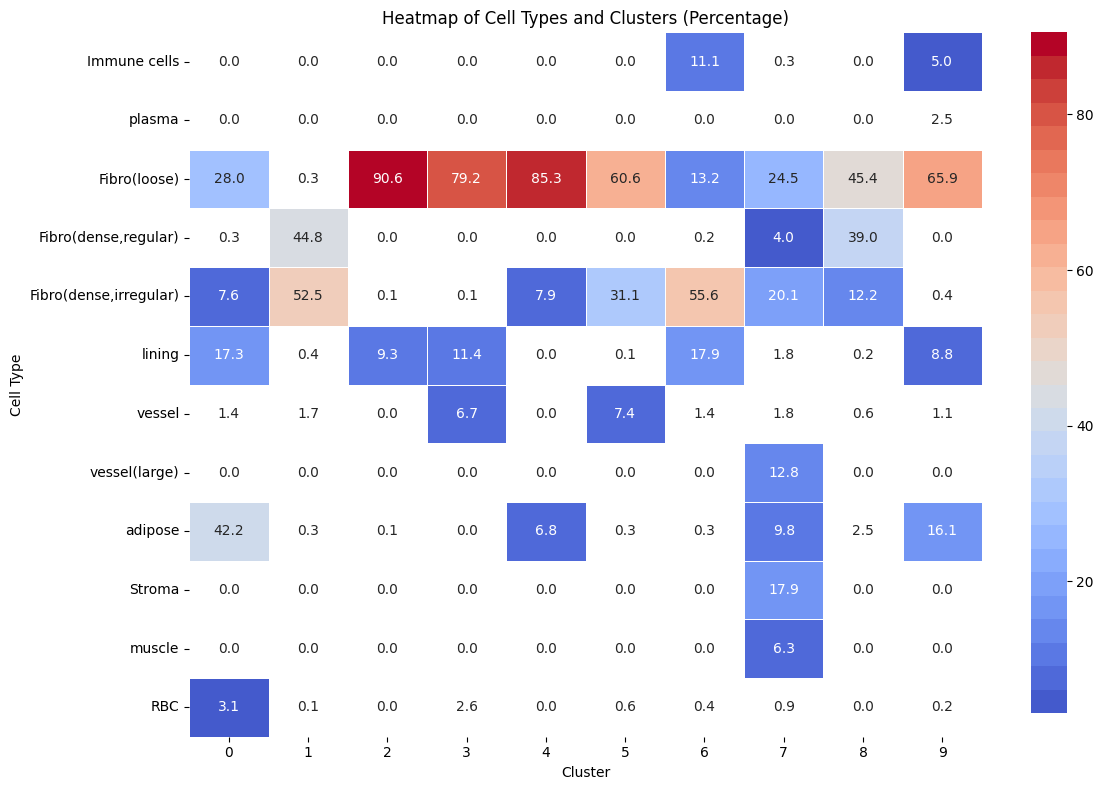

In [54]:
df_ratio_list = []

for patient in patients:
    df = info_dict[patient]["input_df"]
    df2 = df.loc[info_dict[patient]["Result3"].index]
    # 各行の合計を計算
    row_sums = df2.sum(axis=1)
    # 各行をその合計で割る
    df_ratio = df2.div(row_sums, axis=0)

    df_ratio["cluster"] = info_dict[patient]["Cluster3_10"]

    df_ratio_list.append(df_ratio)


df_ratio_merge = pd.concat(df_ratio_list)

df_ratio_merge_mean = df_ratio_merge.groupby("cluster").mean() * 100

className = ["Immune cells", "plasma", "Fibro(loose)", "Fibro(dense,regular)",
"Fibro(dense,irregular)",  "lining", "vessel", "vessel(large)",
"adipose", "Stroma", "muscle", "RBC"]

df_ratio_merge_mean.columns = className


import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ベースとなるカラーマップを作成
base_cmap = sns.color_palette("coolwarm", as_cmap=True)

# 10段階の色を取得
n_colors = 30
colors = [base_cmap(i / (n_colors - 1)) for i in range(n_colors)]
# 先頭に白を入れる
colors = ["white"] + colors[1:]
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors, N=30)

# ヒートマップの作成
plt.figure(figsize=(12, 8))
sns.heatmap(df_ratio_merge_mean.T, annot=True, fmt='.1f', cmap=cmap, linewidths=0.5)
plt.title('Heatmap of Cell Types and Clusters (Percentage)')
plt.xlabel('Cluster')
plt.ylabel('Cell Type')
plt.tight_layout()
plt.savefig("plots/023_GNN_Kmeans3rd_10.pdf")
plt.show()


100%|██████████| 118/118 [00:12<00:00,  9.57it/s]


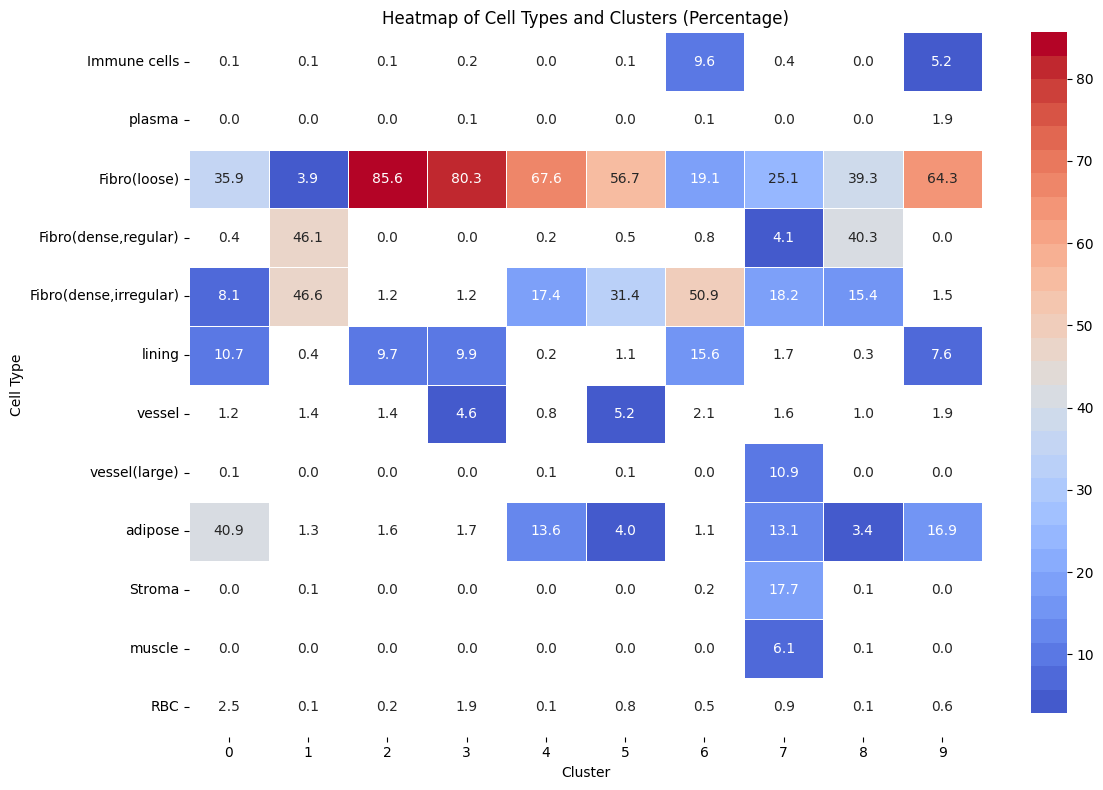

In [56]:
## 5 hop community版

df_ratio_list = []

with h5py.File("GNN_InOut.h5", mode="r") as f:
    patients = list(f.keys())
    for patient in tqdm(patients):
        ratio = f[patient]["community_label_ratio"][:]
        idx = f[patient]["index"][:].astype(str)
        df = pd.DataFrame(ratio, index=idx)
        df2 = df.loc[info_dict[patient]["Result3"].index]

        # 各行の合計を計算
        row_sums = df2.sum(axis=1)
        # 各行をその合計で割る
        df_ratio = df2.div(row_sums, axis=0)
        df_ratio["cluster"] = info_dict[patient]["Cluster3_10"]

        df_ratio_list.append(df_ratio)



df_ratio_merge = pd.concat(df_ratio_list)

df_ratio_merge_mean = df_ratio_merge.groupby("cluster").mean() * 100

className = ["Immune cells", "plasma", "Fibro(loose)", "Fibro(dense,regular)",
"Fibro(dense,irregular)", "lining", "vessel", "vessel(large)",
"adipose", "Stroma", "muscle", "RBC"]

df_ratio_merge_mean.columns = className


import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ベースとなるカラーマップを作成
base_cmap = sns.color_palette("coolwarm", as_cmap=True)

# 10段階の色を取得
n_colors = 30
colors = [base_cmap(i / (n_colors - 1)) for i in range(n_colors)]
# 先頭に白を入れる
colors = ["white"] + colors[1:]
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors, N=30)

# ヒートマップの作成
plt.figure(figsize=(12, 8))
sns.heatmap(df_ratio_merge_mean.T, annot=True, fmt='.1f', cmap=cmap, linewidths=0.5)
plt.title('Heatmap of Cell Types and Clusters (Percentage)')
plt.xlabel('Cluster')
plt.ylabel('Cell Type')
plt.tight_layout()
plt.savefig("plots/024_GNN_Kmeans3rd_10_2.pdf")
plt.show()

In [57]:
adapt_names = {
    0: "Mix_Lining-Adipose-Fibrous-Vessel",
    1: "Hetero_Fibro(dense,regular)-Fibro(dense,irregular)",
    2: "Hetero_Lining-Fibro(loose)",
    3: "Hetero_Lining-Vessel-Fibro(loose)",
    4: "Hetero_Fibro(loose)-Fibro(dense,irregular)-Adipose",
    5: "Hetero_Fibro(loose)-Fibro(dense,irregular)-Vessel",
    6: "Hetero_Lining-Immune-Fibrous",
    7: "Mix_Others",
    8: "Hetero_Fibrous",
    9: "Mix_Lining-Immune-Fibrous-Adipose",
}
adapt_clusters = adapt_names.keys()

for patient in patients:
    # 1症例のindexを取得
    idx = info_dict[patient]['Result3'].index

    # 現在のcluster番号を取得
    kmeans_cluster = info_dict[patient]["Cluster3_10"]

    # 採用clusterを1つずつ処理
    for adapt_cluster in adapt_clusters:
        # 採用clusterを持つ細胞のindex取得
        ids = idx[kmeans_cluster == adapt_cluster]
        # 採用clusterを持つ細胞のクラスター名をid_clusterに登録
        for id in ids:
            info_dict[patient]["id_cluster"][id] = adapt_names[adapt_cluster]


In [58]:
info_dict["D002"]["id_cluster"]

{'5c9f33b1-d224-4e53-900c-9339c6b75b2d': 'Hetero_Fibro(loose)-Adipose',
 '9d5e7de3-0be5-45d5-beb5-ab8a825bd1c9': 'Hetero_Fibro(loose)-Adipose',
 'e4cdbe18-9418-4470-b90a-55e04f491c65': 'Mix_Lining-Adipose-Fibrous-Vessel',
 'ba77f505-9e74-4936-849d-e5b7ffcd3236': 'Hetero_Fibro(loose)-Adipose',
 'f147c9e9-09de-4dba-bed1-893e269121e6': 'Hetero_Fibro(loose)-Adipose',
 'ae6c42f6-47c0-4155-a089-f8641f277c89': 'Mix_Lining-Adipose-Fibrous-Vessel',
 '3c8843a8-dc9e-46f7-a9f1-046ca32c7682': 'Homo_Fibro(loose)',
 '1820c913-42e2-49d2-a882-a66494d5b6ae': 'Homo_Fibro(loose)',
 '71bb90dd-071c-4145-81a9-7b8ec3b58e41': 'Hetero_Fibro(loose)-Adipose',
 '9690c19c-433c-4255-b02b-d2474775fdb0': 'Hetero_Fibro(loose)-Adipose',
 '0f8743ea-a2da-40d9-9b4a-deb0f3a62296': 'Homo_Fibro(loose)',
 '46237421-e54e-43df-9d13-c5de56838099': 'Homo_Fibro(loose)',
 '8c4a393e-822d-474c-bb8f-5e38c2e3483e': 'Hetero_Fibro(loose)-Adipose',
 'c3b17dfb-ff95-4934-91aa-0d2c8f998d06': 'Homo_Fibro(loose)',
 '545b0776-445b-4cb4-b482-bfe0

### 確定クラスターと中心ノードラベルの割合

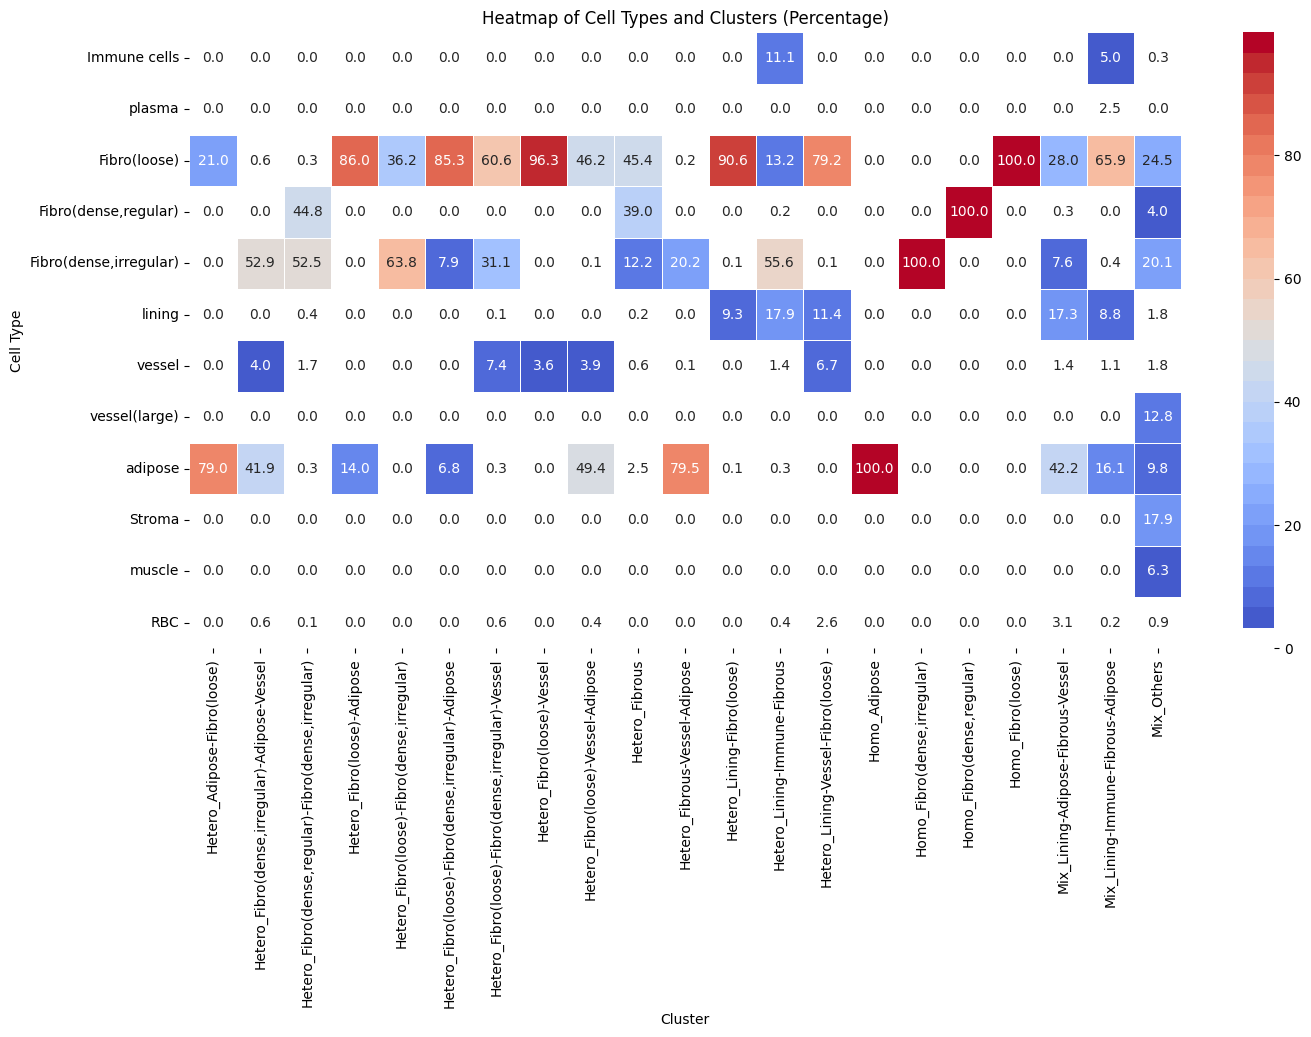

In [62]:
df_ratio_list = []

for patient in patients:
    df = info_dict[patient]["input_df"]
    idx = df.index
    # 各行の合計を計算
    row_sums = df.sum(axis=1)
    # 各行をその合計で割る
    df_ratio = df.div(row_sums, axis=0)

    kmeans_cluster = [ info_dict[patient]["id_cluster"][id] for id in idx]
    df_ratio["cluster"] = kmeans_cluster

    df_ratio_list.append(df_ratio)

df_ratio_merge = pd.concat(df_ratio_list)

df_ratio_merge_mean = df_ratio_merge.groupby("cluster").mean() * 100

className = ["Immune cells", "plasma", "Fibro(loose)", "Fibro(dense,regular)",
"Fibro(dense,irregular)", "lining", "vessel", "vessel(large)",
"adipose", "Stroma", "muscle", "RBC"]

df_ratio_merge_mean.columns = className

df_ratio_merge_mean = df_ratio_merge_mean.sort_index(axis=0)

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ベースとなるカラーマップを作成
base_cmap = sns.color_palette("coolwarm", as_cmap=True)

# 10段階の色を取得
n_colors = 30
colors = [base_cmap(i / (n_colors - 1)) for i in range(n_colors)]
# 先頭に白を入れる
colors = ["white"] + colors[1:]
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors, N=30)

# ヒートマップの作成
plt.figure(figsize=(16, 8))
sns.heatmap(df_ratio_merge_mean.T, annot=True, fmt='.1f', cmap=cmap, linewidths=0.5)
plt.title('Heatmap of Cell Types and Clusters (Percentage)')
plt.xlabel('Cluster')
plt.ylabel('Cell Type')
plt.savefig("plots/025_GNN_cluster.pdf")
plt.show()


### 確定クラスターとコミュニティラベルの割合

100%|██████████| 118/118 [00:13<00:00,  8.49it/s]


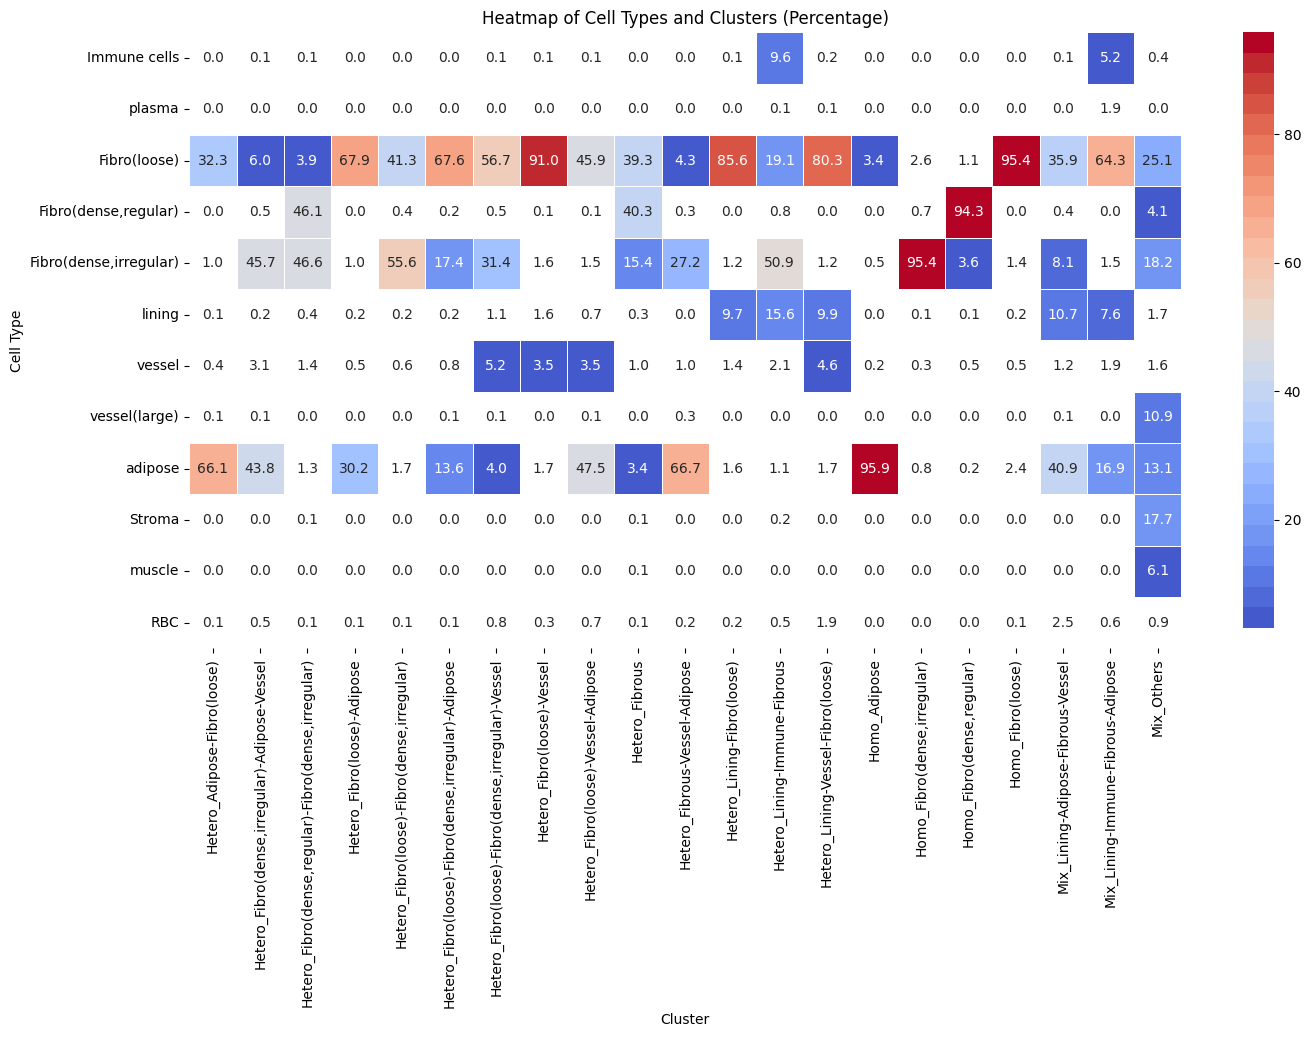

In [63]:
df_ratio_list = []

with h5py.File("GNN_InOut.h5", mode="r") as f:
    patients = list(f.keys())
    for patient in tqdm(patients):
        ratio = f[patient]["community_label_ratio"][:]
        idx = f[patient]["index"][:].astype(str)
        df = pd.DataFrame(ratio, index=idx)

        # 各行の合計を計算
        row_sums = df.sum(axis=1)
        # 各行をその合計で割る
        df_ratio = df.div(row_sums, axis=0)
        kmeans_cluster = [ info_dict[patient]["id_cluster"][id] for id in idx]
        df_ratio["cluster"] = kmeans_cluster

        df_ratio_list.append(df_ratio)


df_ratio_merge = pd.concat(df_ratio_list)

df_ratio_merge_mean = df_ratio_merge.groupby("cluster").mean() * 100

className = ["Immune cells", "plasma", "Fibro(loose)", "Fibro(dense,regular)",
"Fibro(dense,irregular)", "lining", "vessel", "vessel(large)",
"adipose", "Stroma", "muscle", "RBC"]

df_ratio_merge_mean.columns = className


import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ベースとなるカラーマップを作成
base_cmap = sns.color_palette("coolwarm", as_cmap=True)

# 10段階の色を取得
n_colors = 30
colors = [base_cmap(i / (n_colors - 1)) for i in range(n_colors)]
# 先頭に白を入れる
colors = ["white"] + colors[1:]
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors, N=30)

# ヒートマップの作成
plt.figure(figsize=(16, 8))
sns.heatmap(df_ratio_merge_mean.T, annot=True, fmt='.1f', cmap=cmap, linewidths=0.5)
plt.title('Heatmap of Cell Types and Clusters (Percentage)')
plt.xlabel('Cluster')
plt.ylabel('Cell Type')
plt.savefig("plots/026_GNN_cluster_2.pdf")
plt.show()


# このクラスター情報を書き出す

In [64]:
with h5py.File("GNN_InOut.h5", mode="r") as f:
    patients = list(f.keys())
    for patient in tqdm(patients):
        ratio = f[patient]["community_label_ratio"][:]
        idx = f[patient]["index"][:].astype(str)
        df = pd.DataFrame(ratio, index=idx)

        # 各行の合計を計算
        row_sums = df.sum(axis=1)
        # 各行をその合計で割る
        df_ratio = df.div(row_sums, axis=0)
        kmeans_cluster = [ info_dict[patient]["id_cluster"][id] for id in idx]
        df_ratio["cluster"] = kmeans_cluster

        df_ratio_list.append(df_ratio)

100%|██████████| 118/118 [00:13<00:00,  8.98it/s]


In [66]:
with h5py.File("GNN_InOut.h5", mode="a") as f:

    for patient in tqdm(info_dict.keys()):
        _cluster = info_dict[patient]["id_cluster"]
        # h5に記録
        del f[patient]["Cluster"]
        f[patient].create_dataset("Cluster", data = np.array(list(_cluster.values()),dtype="S"), compression = "gzip")

100%|██████████| 118/118 [00:03<00:00, 32.12it/s]


In [67]:
with h5py.File("GNN_InOut.h5", mode="r") as f:
    print(f[patient]["Cluster"][:])

[b'Hetero_Fibro(loose)-Adipose' b'Hetero_Fibro(loose)-Adipose'
 b'Mix_Others' ... b'Mix_Lining-Adipose-Fibrous-Vessel'
 b'Hetero_Fibro(loose)-Vessel' b'Hetero_Fibro(loose)-Vessel']


# BioClinica用にGNNのグラフ書き出し

In [1]:
import os
import numpy as np
import pandas as pd
import tqdm as tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

import torch_geometric
from torch_geometric.data import Data
from torch_geometric.data import NeighborSampler as RawNeighborSampler
from torch_geometric.nn import SAGEConv
from torch_cluster import random_walk

from sklearn.neighbors import radius_neighbors_graph

import networkx as nx
import matplotlib.pyplot as plt
import sklearn.cluster as cluster
import seaborn as sns
import matplotlib.colors as mcolors
from glob import glob
import h5py

In [2]:
f = h5py.File("GNN_InOut.h5", mode="a")

In [5]:
edge_index = f["D001"]["edge_index"][:]
coord = f["D001"]["coord"][:]

In [7]:
edge_index

array([[     0,      1],
       [     0,      2],
       [     0,      3],
       ...,
       [125417, 125410],
       [125417, 125412],
       [125417, 125413]], dtype=int32)

In [6]:
coord

array([[ 3990.55454545,  1766.97636364],
       [ 3977.23793103,  1774.9862069 ],
       [ 4001.18661972,  1791.02464789],
       ...,
       [ 8992.51464844, 13911.41894531],
       [ 9029.08691406, 13912.43847656],
       [ 9070.5862069 , 13912.09770115]])

In [9]:
graph = nx.from_edgelist(edge_index)

In [12]:
coord[:,1] = -coord[:,1]

In [15]:
from matplotlib.backends.backend_pdf import PdfPages
import networkx as nx

# PDFファイルを作成
with PdfPages('plots/GNN_radius_graph_241205.pdf') as pdf:
    plt.figure(figsize=(50,40))
    nx.draw(graph, pos=coord, node_size=1, width=0.2)
    # plt.tight_layout()  # レイアウト調整
    pdf.savefig(bbox_inches="tight")  # 現在のプロットをPDFに保存
    plt.close()  # プロットを閉じる
